<h1 align="center" style="font-size:60px;color:blue;">🧩 DEBI Sales Prediction & Analysis Project</h1>

<p align="center" style="font-size:20px;">
Training project during internship at 
<b style="color:blue;">🏢 DEBI</b><br>
Exploring, analyzing, and predicting sales performance using Machine Learning
</p>

<p align="center" style="font-size:18px;color:blue;">
👨‍💻 Team Members:<br>
<b>Abdelrahman Osama Mohamed Ali</b><br>
<b>Yousit Salah Muhammad Abu Al-Maati</b><br>
<b>Asmaa Ali Abdelaaty Mahmoud</b><br>
<b>Esraa Taha Abdelhasseb Ahmed</b><br>
<b>Aml Abdullah Shehata Zaytoun</b><br>
<b>Hanan Hamdy Mostafa Elabd</b>
</p>


# <p style="font-family:newtimeroman;font-size:130%;text-align:center;color:blue;"> Data Preparation</p>

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math
import plotly.express as px

sns.set(style="whitegrid")
pd.options.display.max_columns = 200


In [2]:
# data = pd.read_csv(r"C:\Users\elfares center net\Downloads\mergedTrain.csv")
data = pd.read_csv(r"../PreparedData/mergedTrain.csv" , parse_dates=["Date"])
data

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\194955315.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"../PreparedData/mergedTrain.csv" , parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


- **Copy data**

In [3]:
df = data.copy()

# Data Understanding 

# 📊 Data Understanding — Sales Dataset (Detailed)

| Column Name | Detailed Description | Data Type | Example Values | Missing Values? | Role | Preprocessing & Analytical Notes |
|--------------|----------------------|------------|----------------|-----------------|------|----------------------------------|
| **Store** | Unique ID representing each store. Used to distinguish different stores and can be used for grouping or encoding. | Integer / Categorical | 1, 2, 3, ... | No | Identifier | Not used directly for prediction unless encoded. Useful for grouping (average sales per store) or target encoding. |
| **DayOfWeek** | Represents the day of the week (1 = Monday, ..., 7 = Sunday). Captures weekly sales patterns. | Integer (1–7) | 1, 5, 7 | No | Feature | Convert to categorical or cyclical features using sin/cos transformations. Visualize average sales per day of week to detect weekly trends. |
| **Date** | The actual calendar date of the record. Used to extract time-related features (year, month, week, etc.). | String → Datetime | 2015-07-31 | No | Feature | Convert to datetime. Extract features such as year, month, day, weekofyear, and weekday. Useful for time series trend analysis. |
| **Sales** | Total daily sales for each store — often the **target variable** in forecasting tasks. | Numeric (Int/Float) | 5263, 13995 | No | **Target** | Check distribution (may require log transform). Sales are typically zero when the store is closed (Open=0). Remove closed days when training predictive models if needed. |
| **Customers** | Number of customers who visited the store that day. Strongly correlated with sales. | Integer | 555, 625, 1498 | No | Feature | Plot `Sales vs Customers` to verify correlation. Be careful using this feature if predicting future sales, since future customer counts may not be known. |
| **Open** | Indicates whether the store was open (1) or closed (0). | Binary (0/1) | 1, 0 | No | Feature / Filter | Use as a filter — most models exclude closed days (Sales=0). Or include as a feature so the model learns zero-sales behavior. |
| **Promo** | Whether a short-term promotion was active on that day. | Binary (0/1) | 1, 0 | No | Feature | Promotions usually boost sales; visualize average sales during promo vs. non-promo days. |
| **StateHoliday** | Indicates a state-level public holiday. Encoded as: “0” = None, “a” = Public holiday, “b” = Easter, “c” = Christmas. | Categorical (Object) | "0", "a", "b", "c" | No | Feature | Encode with label/one-hot encoding. Analyze sales changes during holidays vs. normal days. |
| **SchoolHoliday** | Indicates if the (store’s region) school was closed. | Binary (0/1) | 1, 0 | No | Feature | Useful for modeling foot traffic variations — families might shop differently during school holidays. |
| **StoreType** | Type of the store (a, b, c, d). Represents business scale or layout. | Categorical | "a", "b", "c", "d" | No | Feature | Apply one-hot or label encoding. Compare average sales per store type. |
| **Assortment** | Type of product assortment: “a” = basic, “b” = extra, “c” = extended. | Categorical | "a", "b", "c" | No | Feature | Encode categorically. Analyze sales differences across assortment types. |
| **CompetitionDistance** | Distance to the nearest competitor store (in meters). | Numeric (Float) | 1270.0, 570.0 | Some (≈0.26%) | Feature | Fill missing with median or large placeholder. Investigate correlation between distance and sales — closer competitors may reduce sales. |
| **CompetitionOpenSinceMonth** | Month when the nearest competitor started operating. | Numeric (1–12) | 9, 11, 12 | Yes (~32%) | Feature | Missing = competitor info unknown. Combine with Year to create “competition_open_time” feature. |
| **CompetitionOpenSinceYear** | Year when the nearest competitor started operating. | Numeric (e.g. 2008, 2007) | 2008, 2007 | Yes (~32%) | Feature | Use with Month to estimate how long the competitor has been open (competition age). Missing values can be filled logically or as “unknown”. |
| **Promo2** | Whether the store is participating in a continuous (long-term) promotion campaign. | Binary (0/1) | 1, 0 | No | Feature | Check how ongoing promotions affect sales. Combine with `PromoInterval` to detect active months. |
| **Promo2SinceWeek** | Week number when continuous promotion started. | Numeric (1–52) | 13, 14 | Yes (~50%) | Feature | Combine with `Promo2SinceYear` to determine start date of continuous promo. Missing = not in Promo2 program. |
| **Promo2SinceYear** | Year when continuous promotion started. | Numeric (e.g. 2010, 2011) | 2010, 2011 | Yes (~50%) | Feature | Missing if store not part of Promo2. Convert with `Promo2SinceWeek` into actual start date if needed. |
| **PromoInterval** | Months when Promo2 is repeated (e.g., “Jan,Apr,Jul,Oct”). | Categorical (Object) | “Jan,Apr,Jul,Oct” | Yes (~50%) | Feature | Parse months into binary indicators for whether the current month is within a promo period. |

---

### 🧩 Summary
- **Rows:** 1,017,209  
- **Columns:** 18  
- **Goal:** Understand and predict store sales based on time, promotions, holidays, and competition.  
- **Key Targets:** `Sales`  
- **Key Features:** `Customers`, `Promo`, `StoreType`, `Assortment`, `CompetitionDistance`, and time-ba
otebook or report more organized?


# <p style="font-family:newtimeroman;font-size:120%;text-align:center;color:blue;">EDA</p>

In [4]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
df.sample(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
829879,1105,2,2013-06-18,3772,464,1,1,0,0,c,c,330.0,11.0,2008.0,1,5.0,2013.0,"Feb,May,Aug,Nov"
448173,729,1,2014-05-26,8680,967,1,0,0,0,c,c,8980.0,6.0,2011.0,0,NaN,NaN,NaN
196447,208,4,2015-02-05,2860,448,1,1,0,1,c,a,300.0,4.0,2006.0,0,NaN,NaN,NaN
704697,803,2,2013-10-08,8182,606,1,1,0,0,d,a,1760.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
861938,829,1,2013-05-20,0,0,0,0,a,0,c,a,110.0,NaN,NaN,0,NaN,NaN,NaN


In [6]:
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


In [7]:
df.shape

(1017209, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

# **Insights**
- 1- data has 1017209 rows 18 columns
- 2- range index (0 t0 1017208) means there is no missing data
- 3- data has 5 float64 , 5 obgect and 8 int64 data type
- 4- data has nullumns
- 5- data free of duplicated

In [9]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,1017209.0,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
SchoolHoliday,1017209.0,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
CompetitionDistance,1014567.0,5430.085652,20.0,710.0,2330.0,6890.0,75860.0,7715.3237
CompetitionOpenSinceMonth,693861.0,7.222866,1.0,4.0,8.0,10.0,12.0,3.211832


In [12]:
df.describe(include="object").T

,count,unique,top,freq
StateHoliday,1017209,5,0,592943
StoreType,1017209,4,a,551627
Assortment,1017209,3,a,537445
PromoInterval,509178,3,"Jan,Apr,Jul,Oct",293122


In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,1017209.0,NaN,NaN,NaN,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,NaN,NaN,NaN,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,NaN,NaN,NaN,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,NaN,NaN,NaN,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,NaN,NaN,NaN,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,NaN,NaN,NaN,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,NaN,NaN,NaN,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
StateHoliday,1017209,5,0,592943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SchoolHoliday,1017209.0,NaN,NaN,NaN,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
StoreType,1017209,4,a,551627,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [15]:
cols = df.columns.tolist()
cols

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval']

In [16]:
#Step 1: Get The numerical Features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Step 2: Get The categorical Features
categorical_cols = df.select_dtypes(include=['object']).columns
print(numerical_cols , end =2*"\n" + 10*"  -------" + 2*"\n")
print(categorical_cols)

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear'],
      dtype='object')

  -------  -------  -------  -------  -------  -------  -------  -------  -------  -------

Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')


In [17]:
df.nunique()

Store                         1115
DayOfWeek                        7
Date                           942
Sales                        21734
Customers                     4086
Open                             2
Promo                            2
StateHoliday                     5
SchoolHoliday                    2
StoreType                        4
Assortment                       3
CompetitionDistance            654
CompetitionOpenSinceMonth       12
CompetitionOpenSinceYear        23
Promo2                           2
Promo2SinceWeek                 24
Promo2SinceYear                  7
PromoInterval                    3
dtype: int64

In [18]:
corr = df.corr(numeric_only=True)
corr

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
Store,1.000000,-0.000008,0.005126,0.024325,-0.000047,0.000058,0.000641,-0.026413,-0.050746,-0.004592,0.008488,0.009865,0.038928
DayOfWeek,-0.000008,1.000000,-0.462125,-0.386445,-0.528963,-0.392925,-0.205388,-0.000025,0.000006,-0.000025,0.000168,0.000174,0.000049
Sales,0.005126,-0.462125,1.000000,0.894711,0.678472,0.452345,0.085124,-0.019229,-0.028257,0.012659,-0.091040,0.059558,-0.021127
Customers,0.024325,-0.386445,0.894711,1.000000,0.616768,0.316169,0.071568,-0.102861,-0.030954,0.008931,-0.150159,0.040531,0.028974
Open,-0.000047,-0.528963,0.678472,0.616768,1.000000,0.295042,0.086171,0.007992,0.001384,0.002771,-0.008309,-0.002430,0.001637
Promo,0.000058,-0.392925,0.452345,0.316169,0.295042,1.000000,0.067483,0.000138,-0.000023,0.000152,-0.000983,-0.001008,-0.000283
SchoolHoliday,0.000641,-0.205388,0.085124,0.071568,0.086171,0.067483,1.000000,-0.003689,-0.000526,0.001520,-0.006909,-0.003133,-0.003682
CompetitionDistance,-0.026413,-0.000025,-0.019229,-0.102861,0.007992,0.000138,-0.003689,1.000000,-0.061624,0.025397,-0.139886,-0.054384,-0.109695
CompetitionOpenSinceMonth,-0.050746,0.000006,-0.028257,-0.030954,0.001384,-0.000023,-0.000526,-0.061624,1.000000,-0.060594,-0.009383,-0.036251,0.050326
CompetitionOpenSinceYear,-0.004592,-0.000025,0.012659,0.008931,0.002771,0.000152,0.001520,0.025397,-0.060594,1.000000,-0.077336,-0.079784,0.012155


<Axes: >

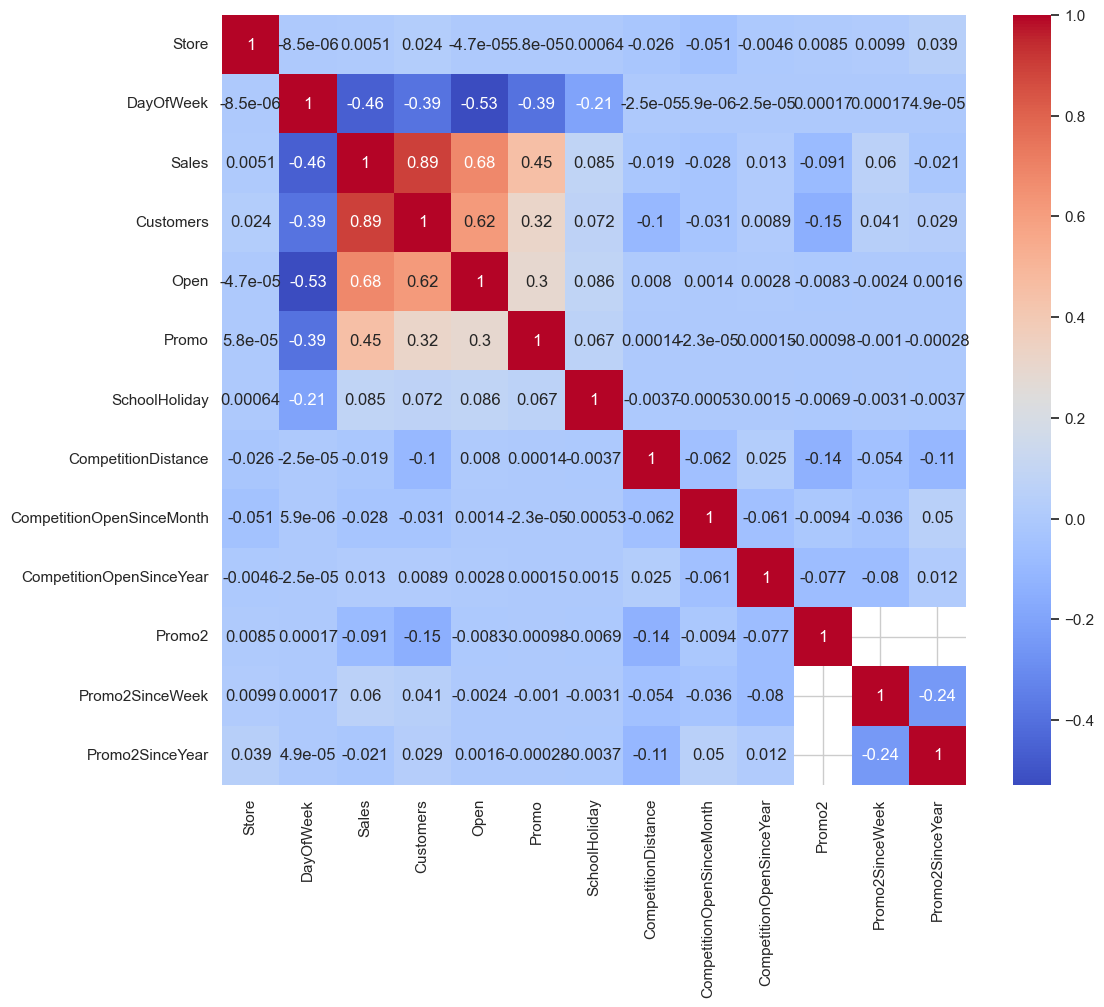

In [19]:
plt.figure(figsize=(12,10))

sns.heatmap(corr,annot=True,cmap='coolwarm')

In [20]:
for column in df.columns:
    print(f"Value counts for column '{column}':\n")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for column 'Store':

Store
1115    942
1       942
2       942
3       942
4       942
       ... 
1067    758
1080    758
22      758
20      758
13      758
Name: count, Length: 1115, dtype: int64

----------------------------------------

Value counts for column 'DayOfWeek':

DayOfWeek
5    145845
4    145845
3    145665
2    145664
1    144730
7    144730
6    144730
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Date':

Date
2013-01-02    1115
2015-07-31    1115
2015-07-30    1115
2015-07-29    1115
2015-07-28    1115
              ... 
2014-12-12     935
2014-12-10     935
2014-12-09     935
2014-12-08     935
2014-12-07     935
Name: count, Length: 942, dtype: int64

----------------------------------------

Value counts for column 'Sales':

Sales
0        172871
5674        215
5558        197
5483        196
6214        195
          ...  
982           1
1173          1
1090          1
1338          1
18841         1

In [21]:
def generate_distribution_plot(df_train, continuous_features):
    data = df_train[continuous_features].copy()
    
    fig, axes = plt.subplots(nrows=len(data.columns)//2, ncols=2, figsize=(20, 20))
    fig.subplots_adjust(hspace=0.7)
    
    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 16,
            }
    
    for ax, feature in zip(axes.flatten(), data.columns):
        feature_mean = data[feature].mean()
        feature_median = data[feature].median()
        feature_mode = data[feature].mode().values[0]
        
        sns.histplot(data[feature], ax=ax, kde=True)  # kde=True adds the KDE curve
        ax.set_title(f'Analysis of {feature}', fontdict=font)
        ax.axvline(feature_mean, color='r', linestyle='--', label="Mean")
        ax.axvline(feature_median, color='g', linestyle='-', label="Median")
        ax.axvline(feature_mode, color='b', linestyle='-', label="Mode")
        ax.legend()
    
    plt.show()

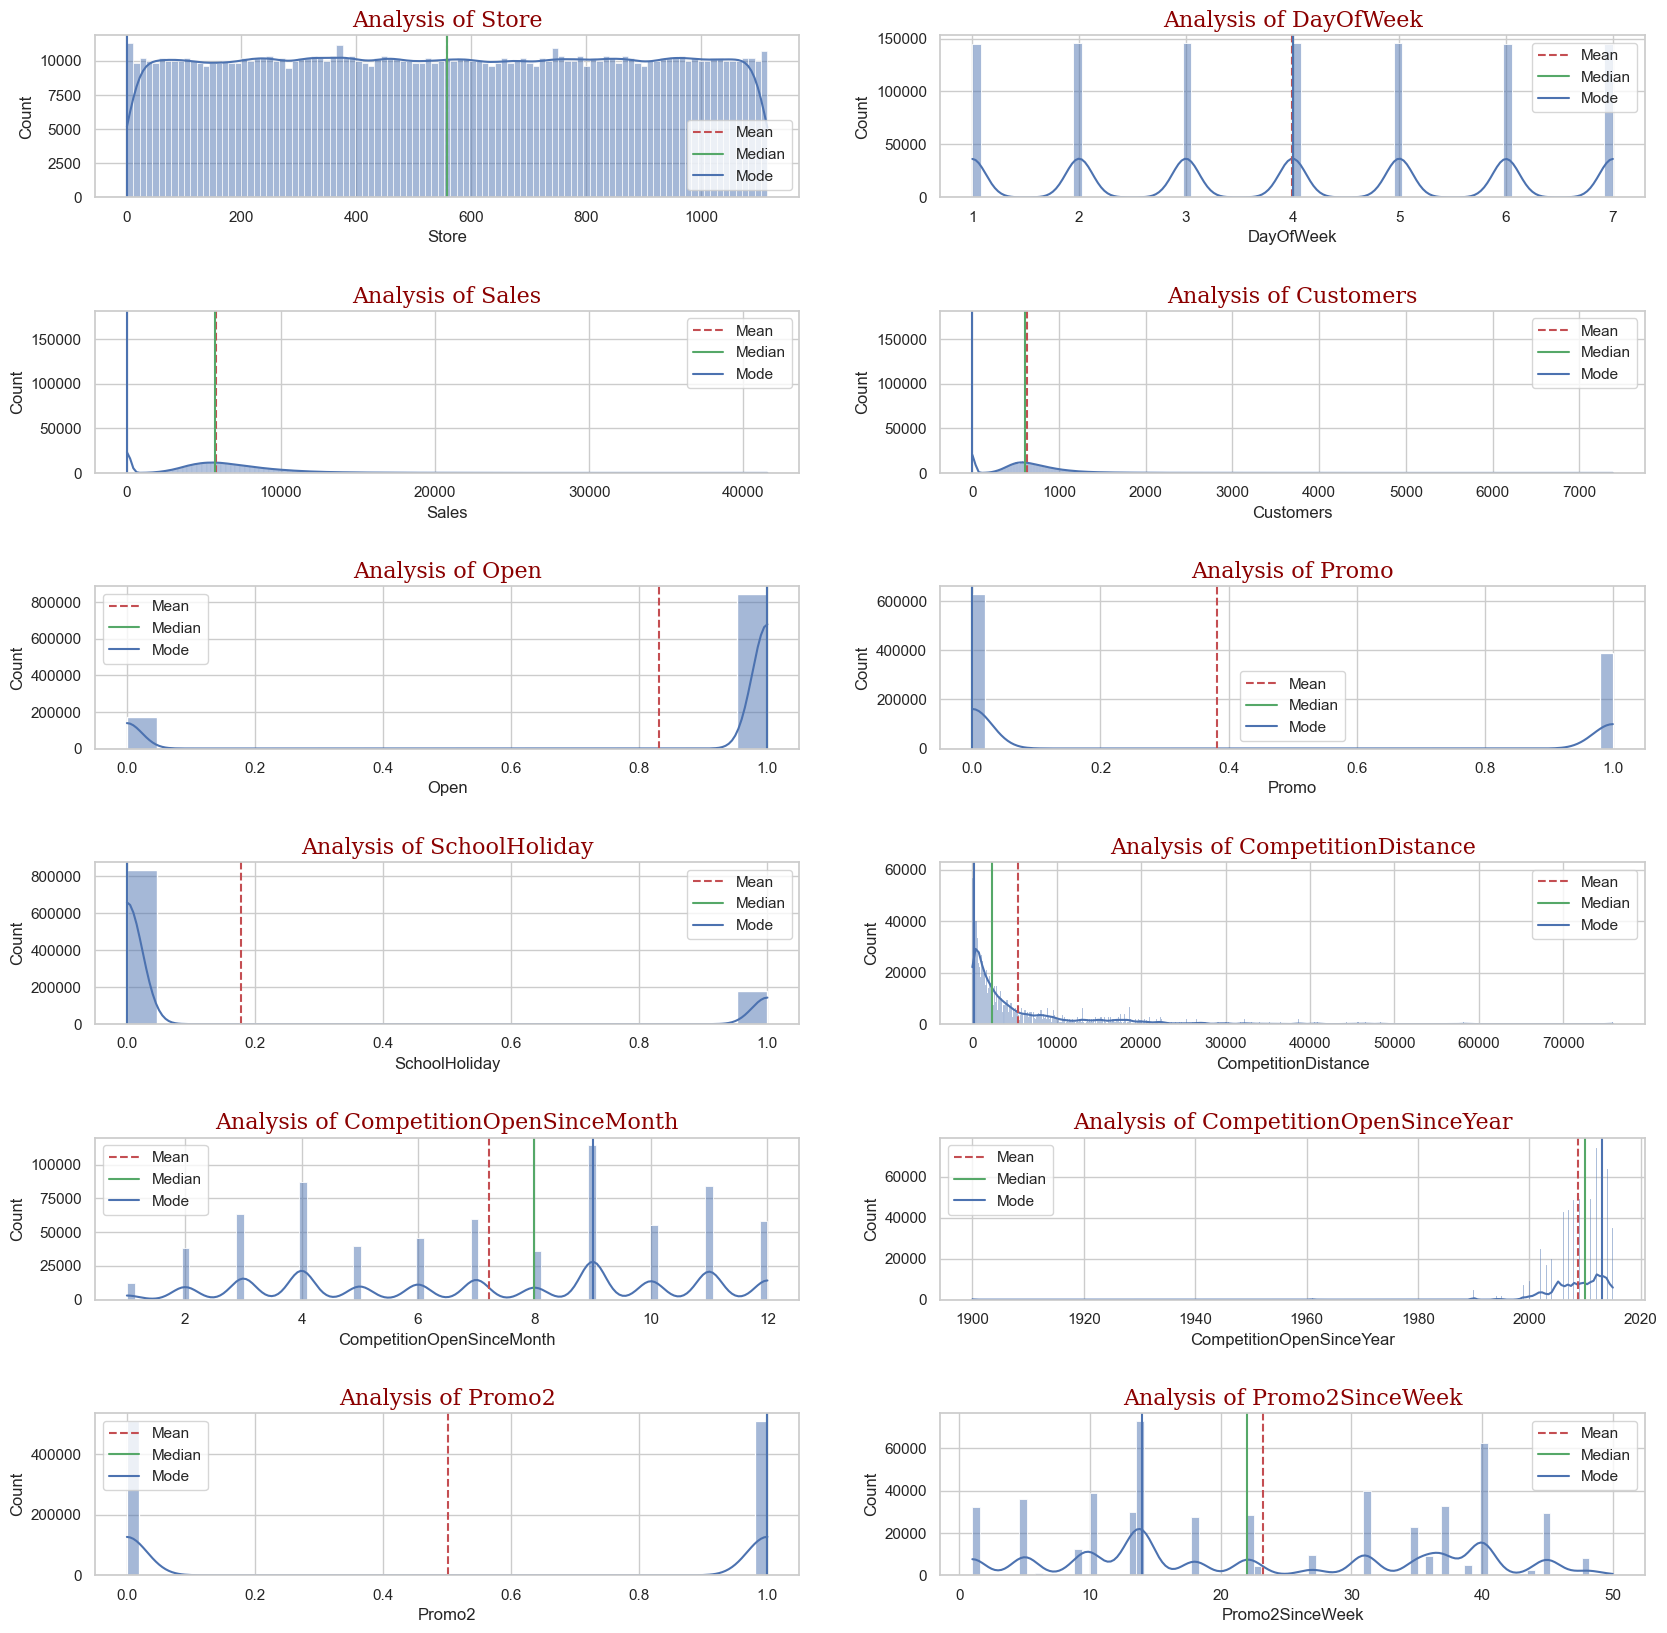

In [22]:
generate_distribution_plot(df, numerical_cols)

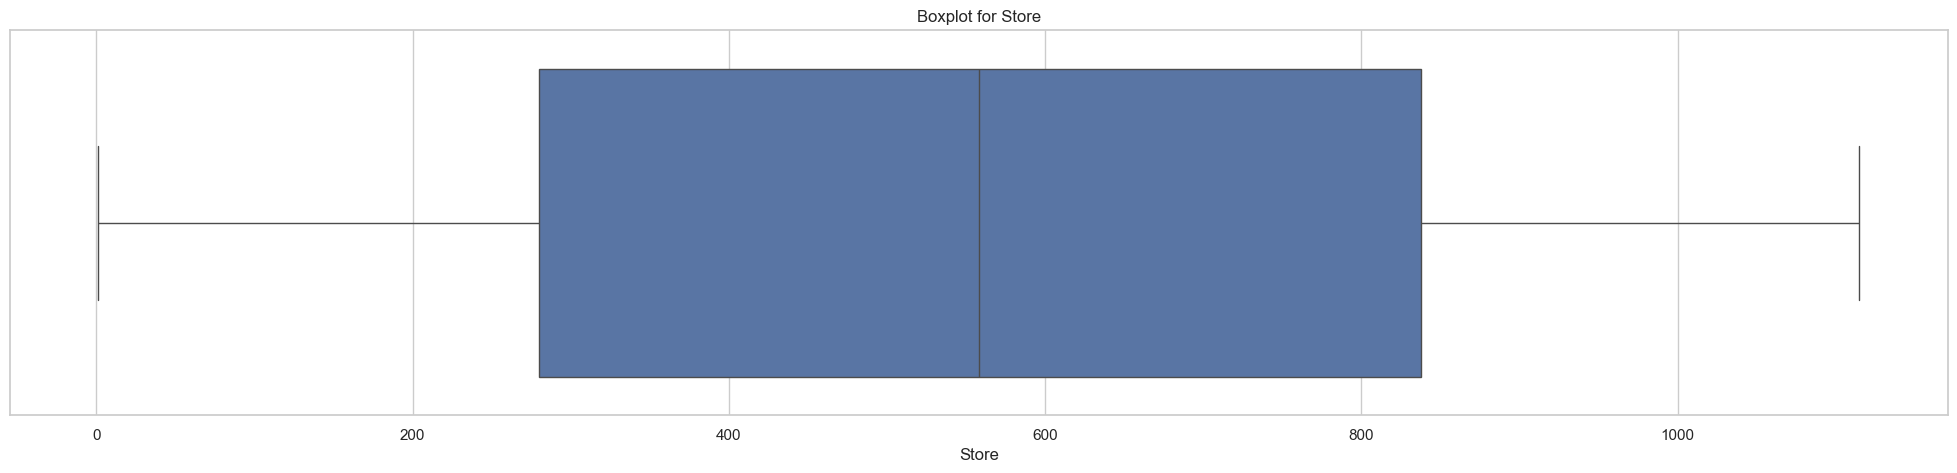

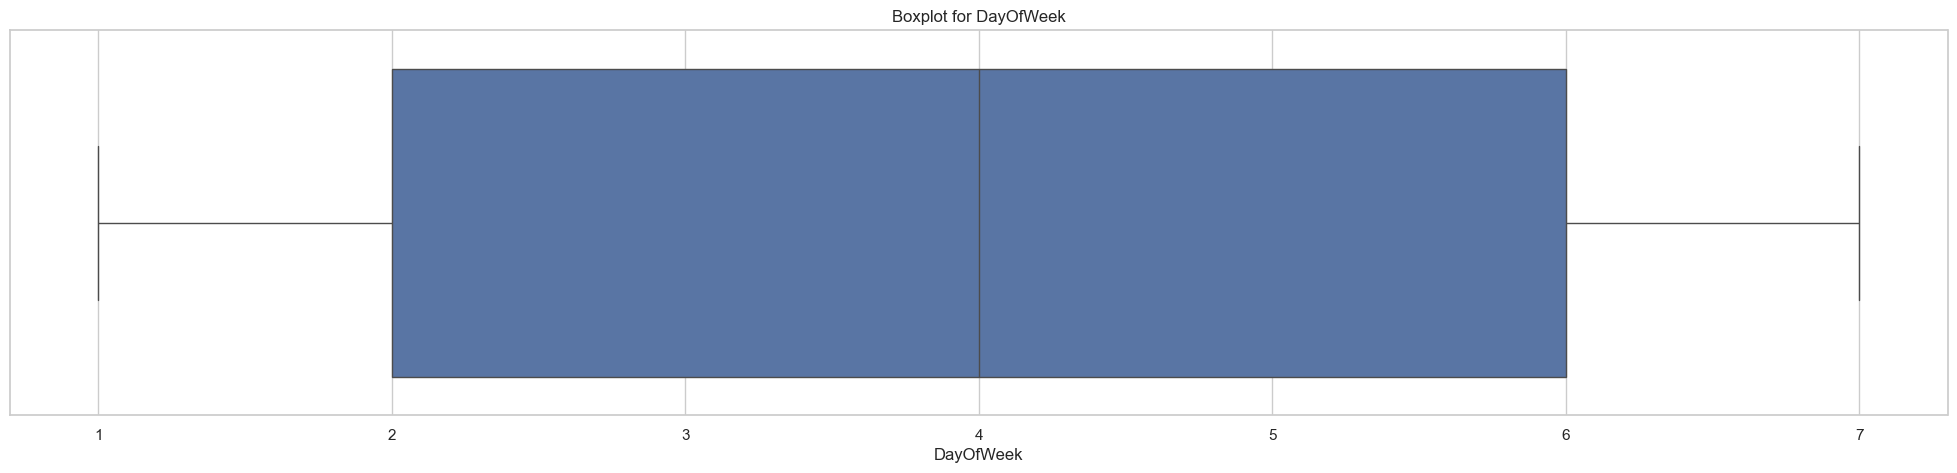

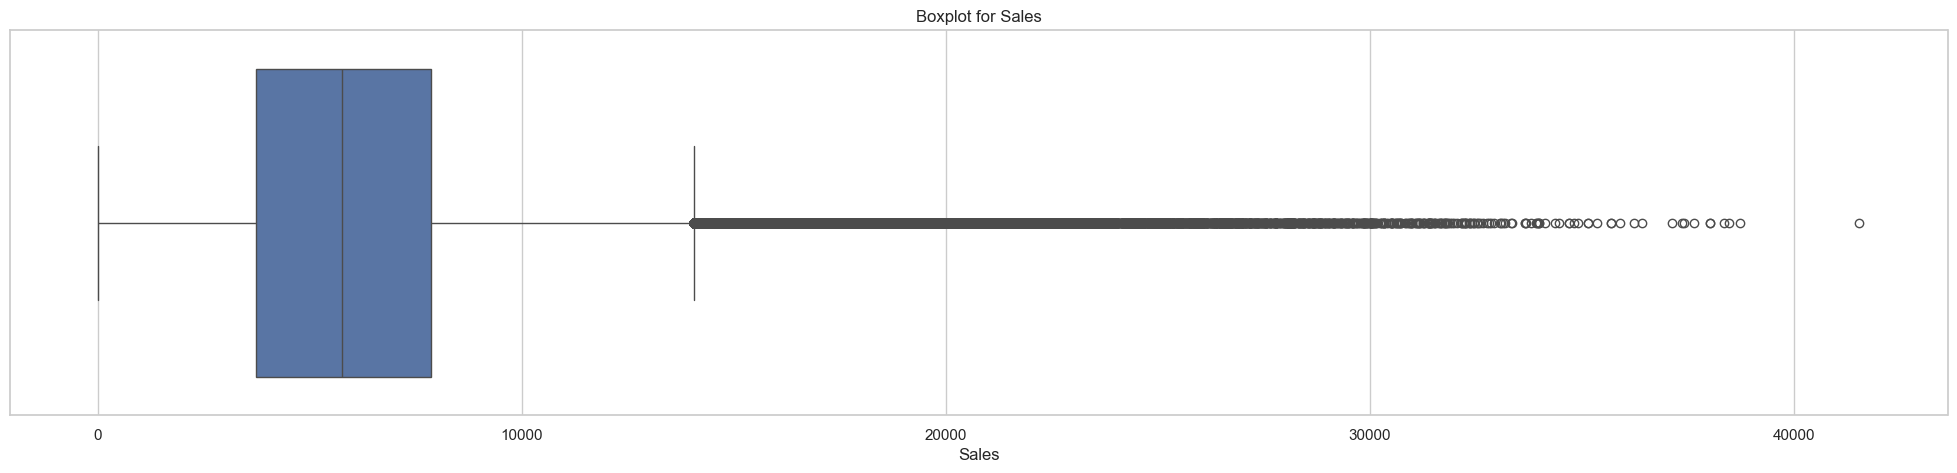

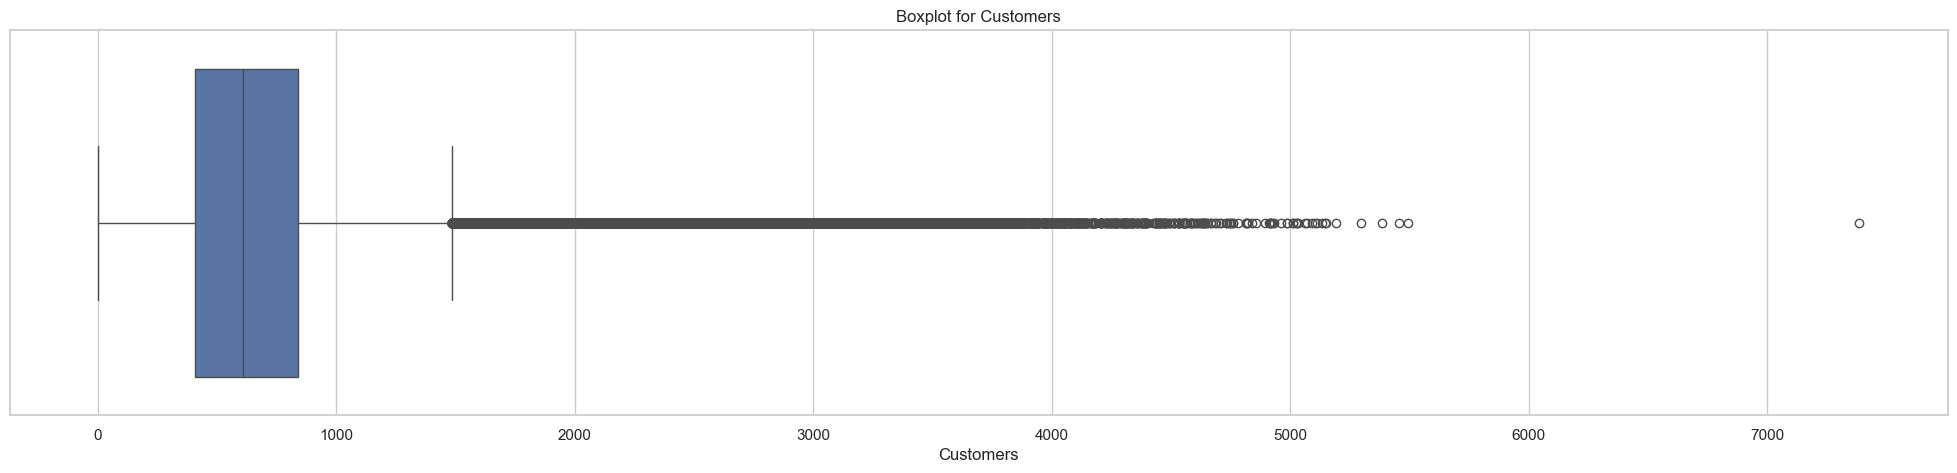

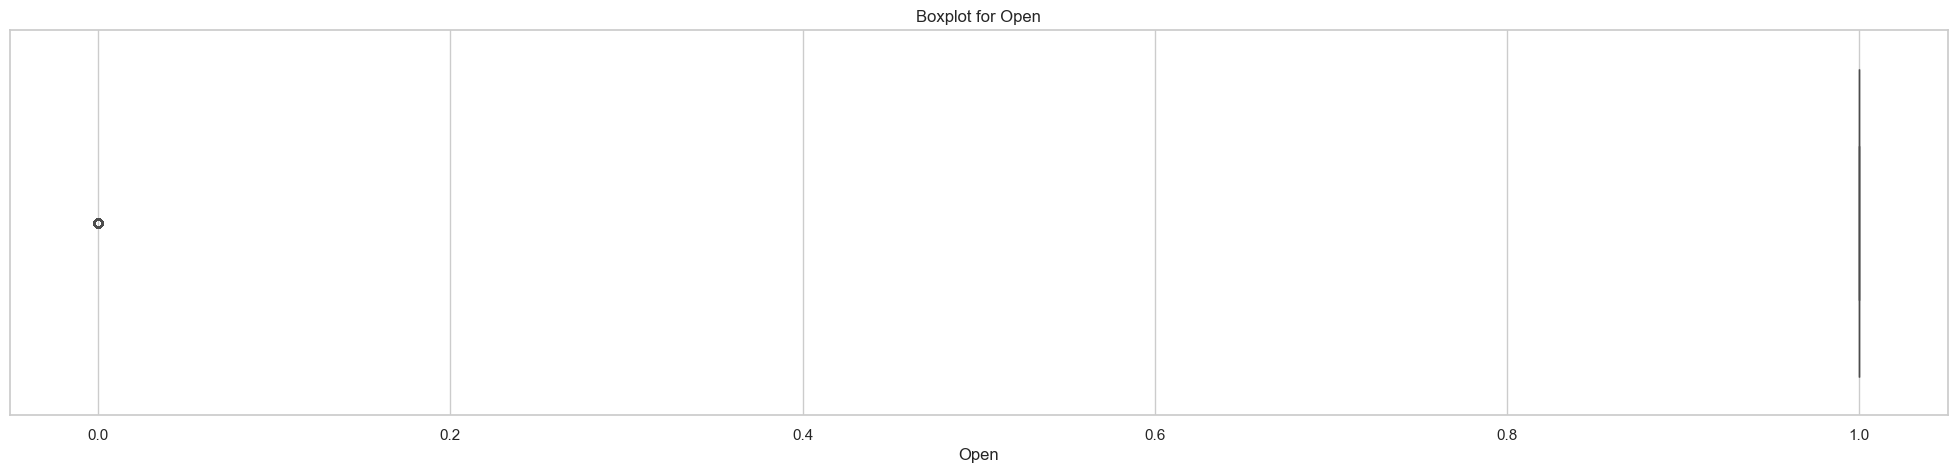

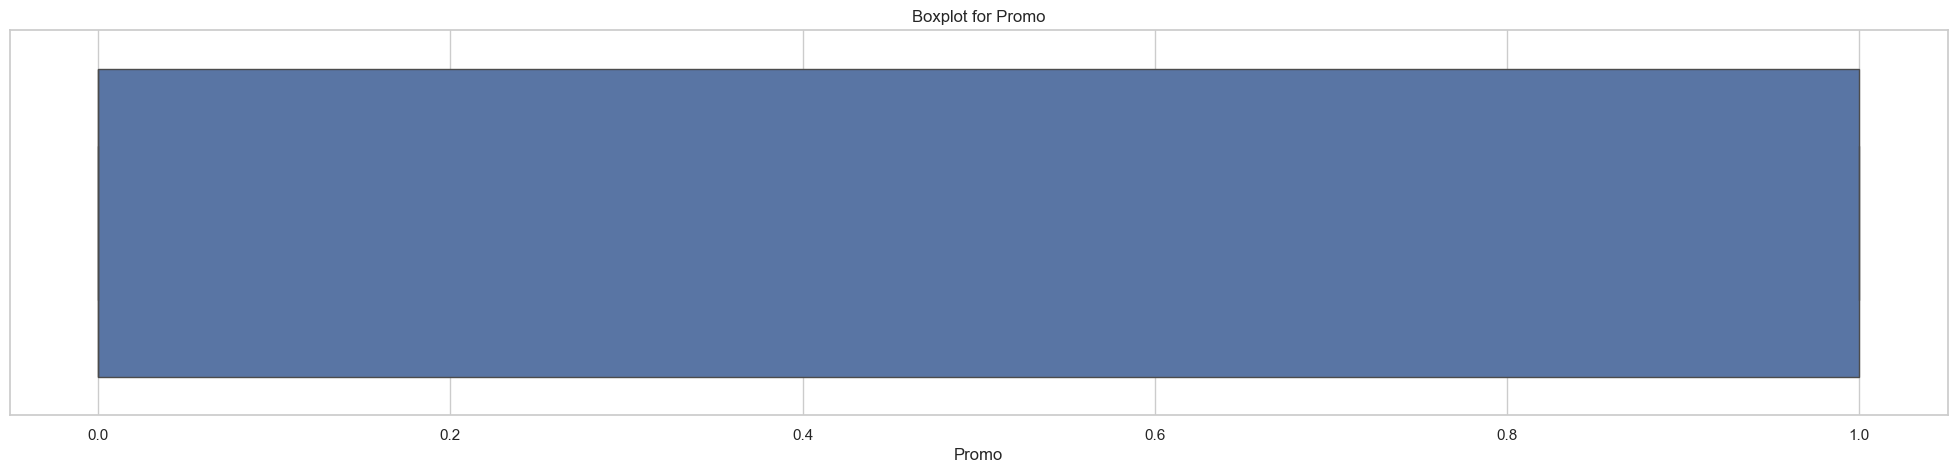

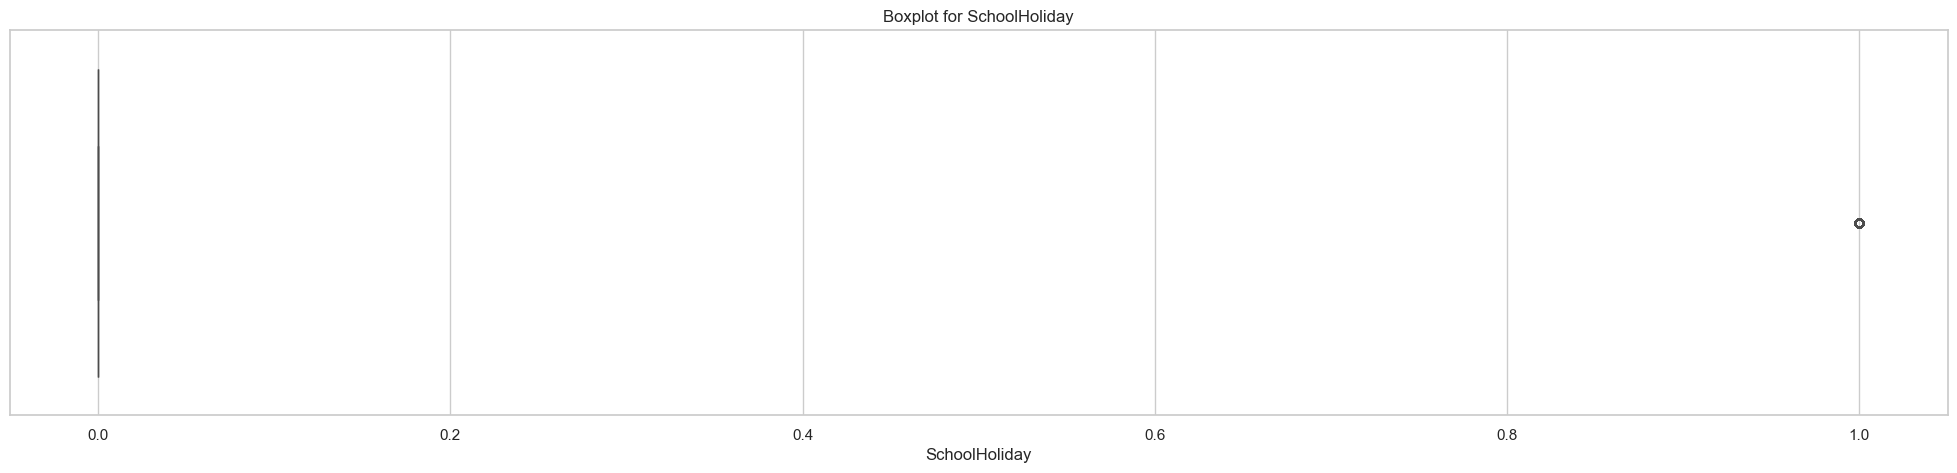

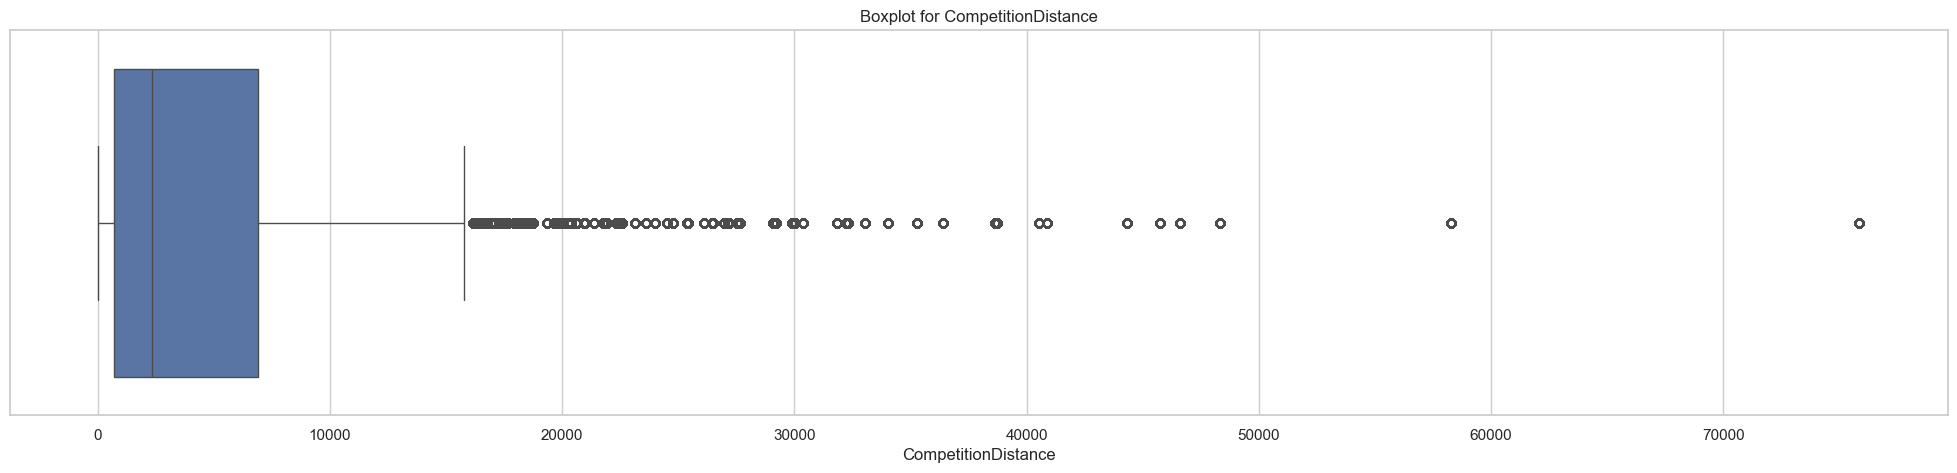

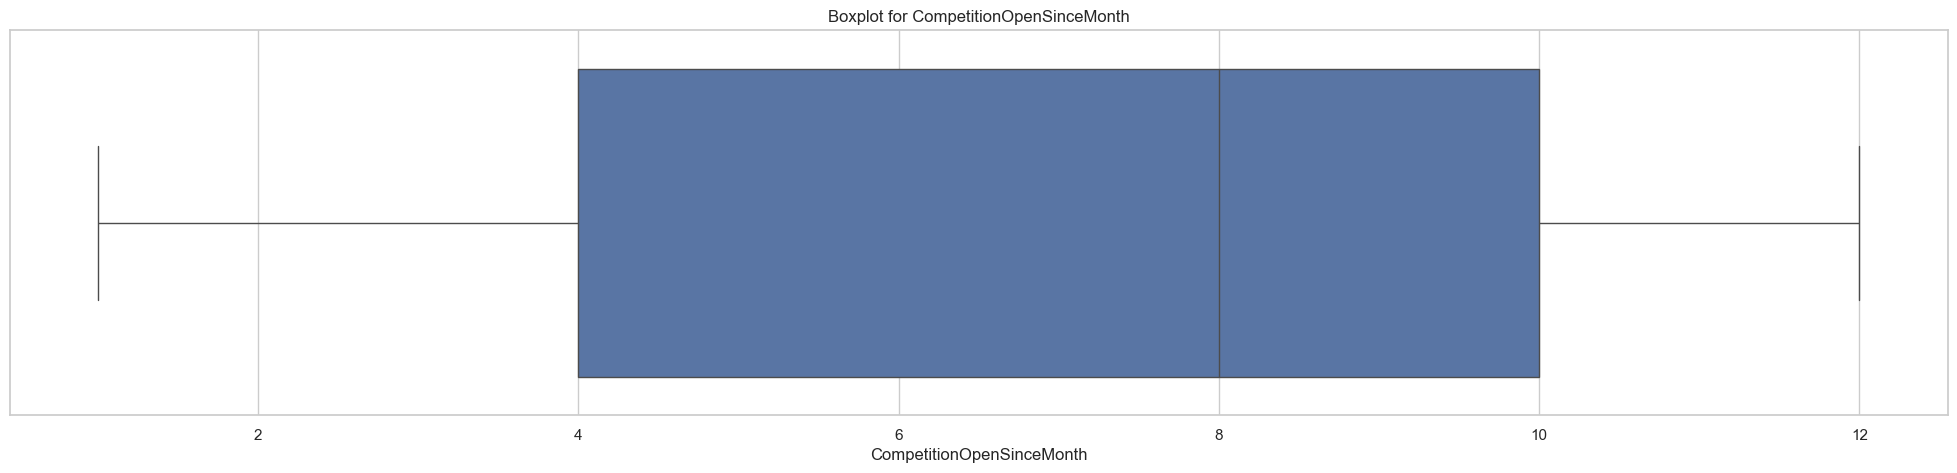

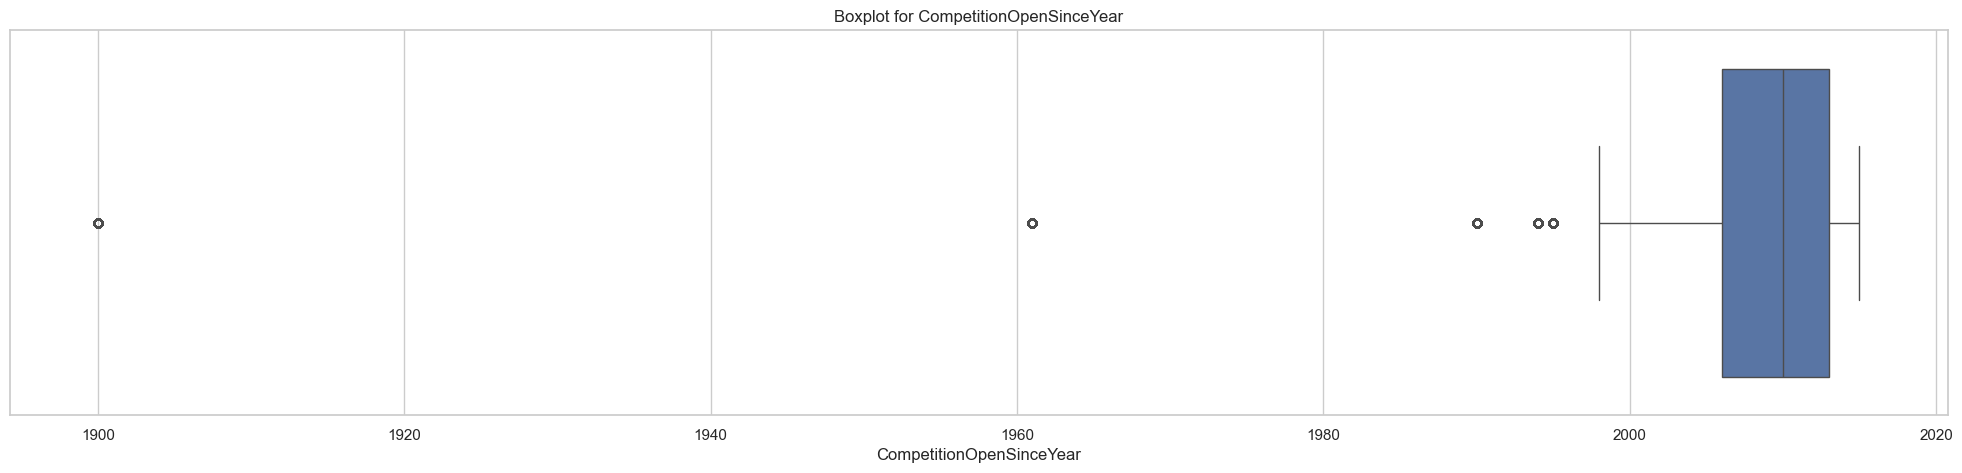

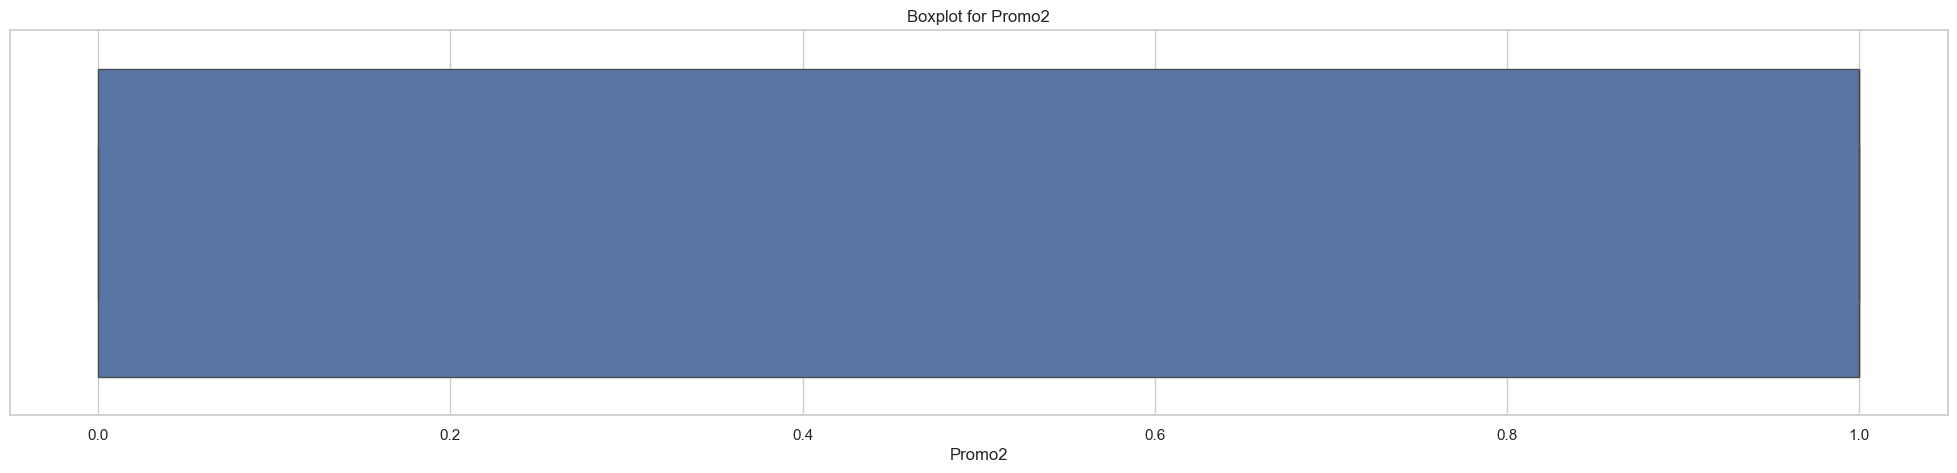

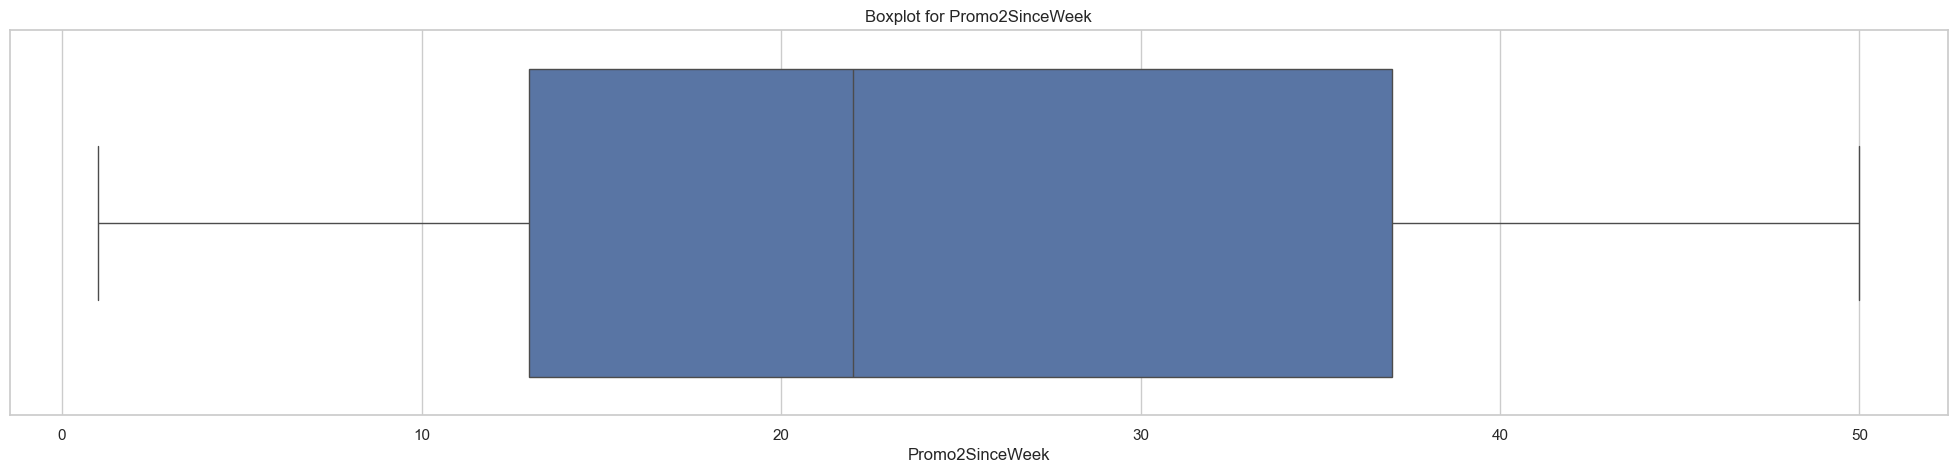

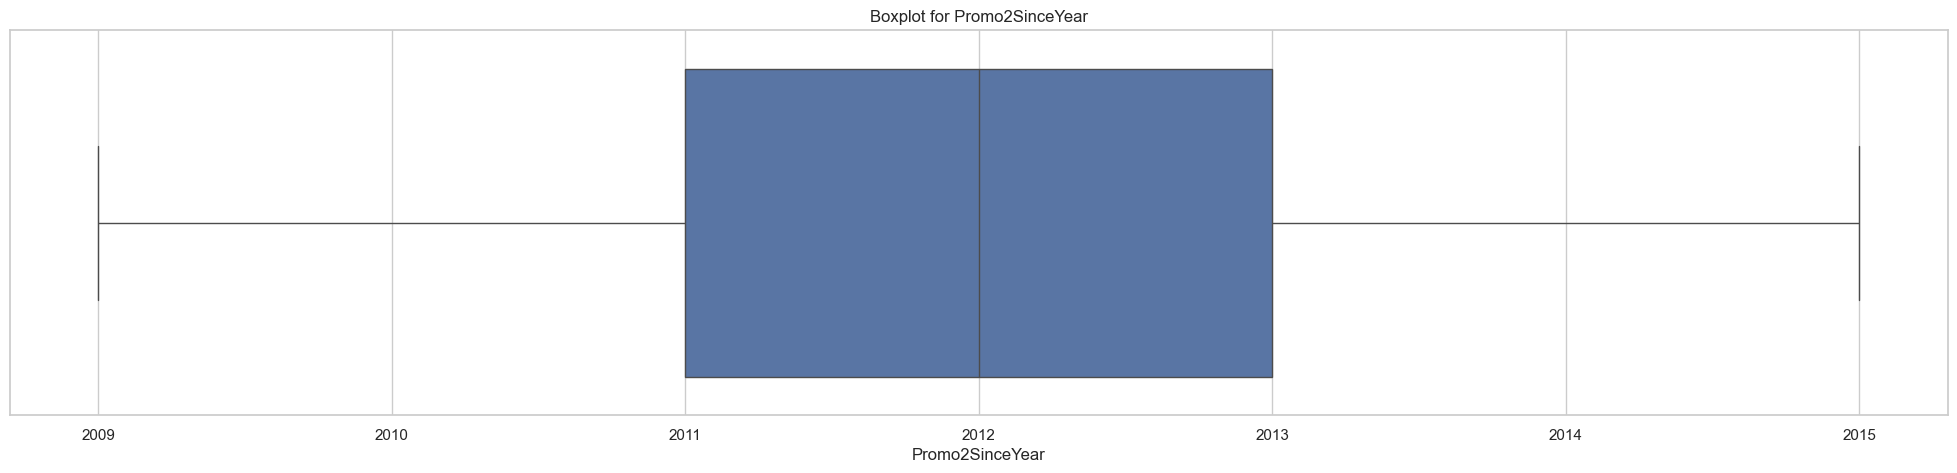

In [23]:
for i in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(25, 5))  # Set the figure size
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot for {i}')
    plt.show()


In [24]:
#check outliers
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier condition
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Print result
    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print("Outlier values:")
        print(outliers[col].values[:10])  # Show first 10 outlier values
    else:
        print("No outliers detected.")
    print("-" * 40)


Column: Store
Number of outliers: 0
No outliers detected.
----------------------------------------
Column: DayOfWeek
Number of outliers: 0
No outliers detected.
----------------------------------------
Column: Sales
Number of outliers: 26694
Outlier values:
[15344 14190 14180 14949 14927 18227 16191 17286 22205 14096]
----------------------------------------
Column: Customers
Number of outliers: 38095
Outlier values:
[1498 1586 2041 1659 2508 2628 3669 2316 2592 2049]
----------------------------------------
Column: Open
Number of outliers: 172817
Outlier values:
[0 0 0 0 0 0 0 0 0 0]
----------------------------------------
Column: Promo
Number of outliers: 0
No outliers detected.
----------------------------------------
Column: SchoolHoliday
Number of outliers: 181721
Outlier values:
[1 1 1 1 1 1 1 1 1 1]
----------------------------------------
Column: CompetitionDistance
Number of outliers: 99160
Outlier values:
[29910. 24000. 18010. 30360. 22560. 17500. 22440. 19960. 22390. 16690.

In [25]:
#corrolation sales with promotion , holiday

df_corr = df[['Sales', 'Promo', 'SchoolHoliday']].copy()

df_corr['SchoolHoliday'] = pd.to_numeric(df_corr['SchoolHoliday'], errors='coerce')
df_corr['Promo'] = pd.to_numeric(df_corr['Promo'], errors='coerce')
df_corr['Sales'] = pd.to_numeric(df_corr['Sales'], errors='coerce')

df_corr = df_corr.dropna()

correlation = df_corr.corr()

print("Correlation of Sales with Promo and SchoolHoliday:")
print(correlation['Sales'][['Promo', 'SchoolHoliday']])


Correlation of Sales with Promo and SchoolHoliday:
Promo            0.452345
SchoolHoliday    0.085124
Name: Sales, dtype: float64


In [26]:
#Grouped Averages (Categorical Patterns)

print("Average Sales by Promo:")
print(df.groupby('Promo')['Sales'].mean())


print("\nAverage Sales by DayOfWeek:")
print(df.groupby('DayOfWeek')['Sales'].mean())

print("\nAverage Sales by StoreType:")
print(df.groupby('StoreType')['Sales'].mean())


Average Sales by Promo:
Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

Average Sales by DayOfWeek:
DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

Average Sales by StoreType:
StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64


In [27]:
#Pivot Table (Multi-variable Pattern)

pivot = df.pivot_table(values='Sales', index='DayOfWeek', columns='Promo', aggfunc='mean')
print("\nSales Pattern by DayOfWeek and Promo:")
print(pivot)



Sales Pattern by DayOfWeek and Promo:
Promo                0            1
DayOfWeek                          
1          5604.357608  9707.808423
2          5612.048396  8227.909603
3          5418.548638  7554.021384
4          5097.574306  7259.497280
5          6178.610459  7202.540577
6          5847.562599          NaN
7           204.183189          NaN


# <p style="font-family:newtimeroman;font-size:130%;text-align:center;color:blue;"> Preprocessing</p>

# Handle Data Types

In [28]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert categorical features to category dtype
cat_cols = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
for col in cat_cols:
    df[col] = df[col].astype('category')


# Handle Missing Values

In [29]:
# Fill missing numeric values
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)

# Fix categorical column issue
if pd.api.types.is_categorical_dtype(df['PromoInterval']):
    # Add 'None' to categories if not already present
    if 'None' not in df['PromoInterval'].cat.categories:
        df['PromoInterval'] = df['PromoInterval'].cat.add_categories('None')
        
df['PromoInterval'] = df['PromoInterval'].fillna('None')

# Missing competition or promo info likely means “no data available” or “not applicable.”
#Replacing with 0 or 'None' prevents issues in ML models.

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\899628571.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df['PromoInterval']):


# Feature Engineering

In [30]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayOfMonth'] = df['Date'].dt.day
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)
df['CompetitionAge'] = df['Year'] - df['CompetitionOpenSinceYear']
df['Promo2Duration'] = df['Year'] - df['Promo2SinceYear']
df['SalesPerCustomer'] = df['Sales'] / df['Customers']


# Replace any negative or unrealistic durations with 0
df['CompetitionAge'] = df['CompetitionAge'].apply(lambda x: x if x > 0 else 0)
df['Promo2Duration'] = df['Promo2Duration'].apply(lambda x: x if x > 0 else 0)


# Drop Unnecessary Columns

In [31]:
df = df[df['Open'] == 1]

In [32]:
# ✅ Columns to remove before encoding and modeling
cols_to_drop = [
    # 🔹 Identification & Redundant Columns
    #'Store',            # ID-like column — not analytical, may cause overfitting
    #'Date',             # Redundant — info already extracted into Month & Year

    # 🔹 Data Leakage / Target-related
    #'Customers',        # Highly correlated with Sales (target variable)
    #'Open',             # Used earlier to filter closed stores (Open=0)

    # 🔹 Low-value or messy columns
    'PromoInterval',    # Many missing values, adds little predictive value

    # 🔹 Original columns replaced by engineered ones
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear'
]

# Drop all unnecessary columns
df = df.drop(columns=cols_to_drop, errors='ignore')

# ✅ Confirmation
print("✅ All unnecessary columns removed successfully!")
print("Dropped columns:")
for col in cols_to_drop:
    print(f" - {col}")


✅ All unnecessary columns removed successfully!
Dropped columns:
 - PromoInterval
 - CompetitionOpenSinceMonth
 - CompetitionOpenSinceYear
 - Promo2SinceWeek
 - Promo2SinceYear


# Handle Outliers

## 🧹 Outlier Treatment

This section identifies and treats **outliers** in the dataset to improve data quality and model performance.

---

### 📊 Outlier Summary

| Column | Number of Outliers | Interpretation | Recommended Action |
|:--------|:------------------:|:---------------|:------------------|
| **Store** | 0 | Store IDs are categorical numbers — no outliers expected. | ✅ No action needed |
| **DayOfWeek** | 0 | Days are from 1–7 — valid range. | ✅ No action needed |
| **Sales** | 26,694 | High sales spikes due to holidays or promotions. | ⚠️ Keep them (clip extreme ones if necessary). |
| **Customers** | 38,095 | High customer counts likely during promotions. | ⚠️ Keep or slightly clip extreme values. |
| **Open** | 172,817 | 0 indicates closed stores — valid data. | ✅ No action (consider filtering `Open=0`). |
| **Promo** | 0 | Valid binary values (0/1). | ✅ No action needed |
| **SchoolHoliday** | 181,721 | Indicates holidays — valid binary values. | ✅ No action needed |
| **CompetitionDistance** | 99,160 | Extremely large distances — potential skew. | ⚠️ Apply log transformation to reduce skewness. |
| **CompetitionOpenSinceMonth** | 0 | Values within 1–12 — valid. | ✅ No action needed |
| **CompetitionOpenSinceYear** | 9,994 | Unrealistic early years (e.g., 1900–1995). | ⚠️ Replace with median or most frequent year. |
| **Promo2** | 0 | Valid binary values (0/1). | ✅ No action needed |
| **Promo2SinceWeek** | 0 | Valid week numbers. | ✅ No action needed |
| **Promo2SinceYear** | 0 | Valid years. | ✅ No action needed |
| **Month** | 0 | Values between 1–12 — valid. | ✅ No action needed |

---

### 🧠 Insights

- Outliers in **Sales** and **Customers** represent special events or holidays — they’re informative, not errors.  
- Outliers in **CompetitionDistance** and **CompetitionOpenSinceYear** can distort model training.  
- Binary columns like `Open` and `SchoolHoliday` should remain untouched.

---



In [33]:
# ✅ 1️⃣ Function: Treat general outliers using IQR
def treat_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = np.where(
        data[column] > upper, upper,
        np.where(data[column] < lower, lower, data[column])
    )
    return data


# ✅ 2️⃣ Apply IQR treatment to numeric columns (excluding ID-like columns)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col not in ['Store', 'Customers', 'Open']:
        df = treat_outliers_iqr(df, col)


# ✅ 3️⃣ Log-transform CompetitionDistance (only if it exists)
if 'CompetitionDistance' in df.columns:
    df['CompetitionDistance'] = np.log1p(df['CompetitionDistance'])


# ✅ 4️⃣ Clip extreme values for key metrics (Sales only, since Customers was dropped)
def clip_outliers(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)
    return df

if 'Sales' in df.columns:
    df = clip_outliers(df, 'Sales')


# ✅ 5️⃣ Remove closed stores step removed (since 'Open' column was dropped)


# ✅ 6️⃣ Summary
print("✅ Outlier Treatment Completed Successfully!")
print(f"Remaining Rows: {df.shape[0]}")
print(f"Columns Processed (excluding dropped ones): {len(num_cols)}")


✅ Outlier Treatment Completed Successfully!
Remaining Rows: 844392
Columns Processed (excluding dropped ones): 13


# ---------------------------------------------------------
# **(Encode Categorical Columns & FEATURE SELECTION & Define Features and Target & Split Data into Train/Test & Scale Numerical Features)**
# **After data analysis and before modeling**
# ---------------------------------------------------------

# <p style="font-family:newtimeroman;font-size:130%;text-align:center;color:blue;"> Data Analysis & Visualization</p>

# ---------------------
# **Dashboard**
# ----------------------

In [34]:
#Total Stores
total_stores = df['Store'].nunique()
total_stores 
#Total Sales
total_sales = df['Sales'].sum()
total_sales
#Total Customers
total_customers = df['Customers'].sum()
total_customers
#Average Daily Sales
avg_daily_sales = df['Sales'].mean()
avg_daily_sales
#Define Active Store
df['Active'] = ((df['Open'] == 1) & (df['Promo'] == 1)).astype(int)
#Activation Rate
activation_rate = df['Active'].mean() * 100
activation_rate
#  Activation Over Time
activation_daily = df.groupby('Date')['Active'].mean().reset_index()


In [35]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_stores,
    title={"text": "Total Stores"},
    domain={'x':[0,0.3],'y':[0.6,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=total_sales,
    title={"text": "Total Sales"},
    domain={'x':[0.35,0.65],'y':[0.6,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=total_customers,
    title={"text": "Total Customers"},
    domain={'x':[0.7,1],'y':[0.6,1]}
))

fig.add_trace(go.Indicator(
    mode="number+gauge",
    value=activation_rate,
    title={"text": "Activation Rate (%)"},
    gauge={'axis': {'range':[0,100]}},
    domain={'x':[0.25,0.75],'y':[0,0.5]}
))

fig.update_layout(height=700, width=1000, title=" Dashboard")
fig.show()


In [36]:
import plotly.express as px

fig = px.line(
    activation_daily,
    x='Date',
    y='Active',
    title='Daily Activation Rate'
)
fig.show()


# *📊* **Data Visualization**

This section uses **visualizations** to explore key aspects of the sales data, including **sales trends, seasonal patterns, promotional effects, and customer behavior**.  
These charts allow for **in-depth exploration and easy comparison** across different dimensions of the data.


# **Univariate Analysis**

# 1️⃣Distribution of Sales

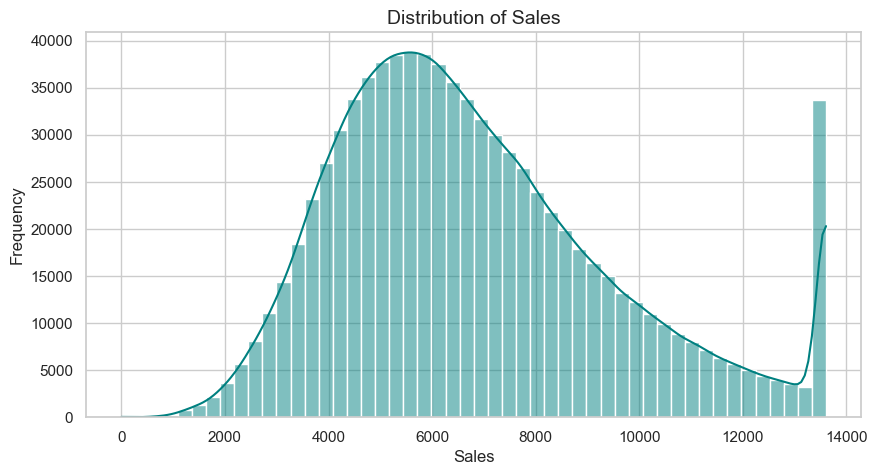

In [37]:
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=50, kde=True, color='teal')
plt.title('Distribution of Sales', fontsize=14)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()


💡 **Insight:**  
Sales are **right-skewed**, meaning most transactions fall under lower sales values,  
while a few stores achieve exceptionally high sales — potential outliers or high-performing stores.


# 2️⃣Distribution of Customers

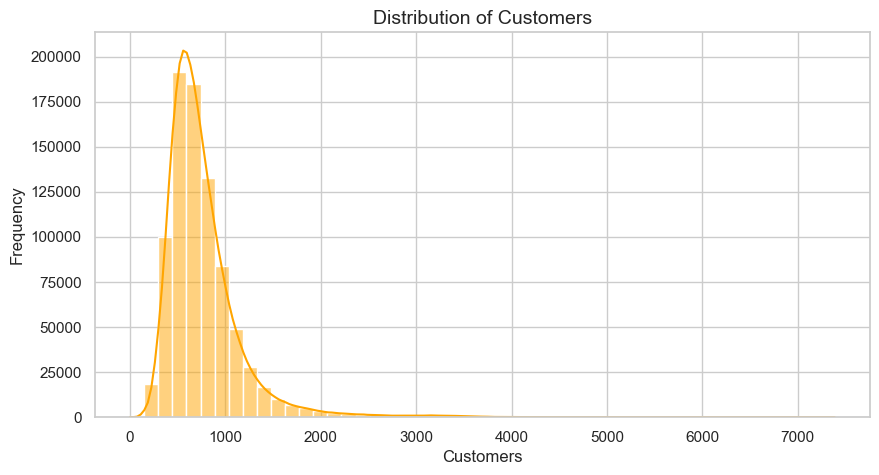

In [38]:
plt.figure(figsize=(10,5))
sns.histplot(df['Customers'], bins=50, kde=True, color='orange')
plt.title('Distribution of Customers', fontsize=14)
plt.xlabel('Customers')
plt.ylabel('Frequency')
plt.show()

💡 **Insight:**  
Customer counts also follow a **right-skewed** pattern, similar to sales,  
which suggests that most stores have moderate customer flow while only a few are very busy.


# 3️⃣Day of Week Distribution

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\3171681045.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




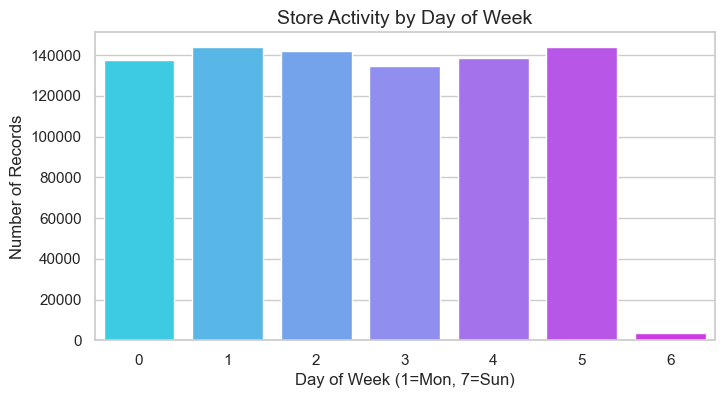

In [39]:
plt.figure(figsize=(8,4))
sns.countplot(x='DayOfWeek', data=df, palette='cool')
plt.title('Store Activity by Day of Week', fontsize=14)
plt.xlabel('Day of Week (1=Mon, 7=Sun)')
plt.ylabel('Number of Records')
plt.show()

# 4️⃣ Store Type Distribution

In [40]:
df['StoreType'].value_counts()

StoreType
a    457077
d    258774
c    112978
b     15563
Name: count, dtype: int64

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\300974008.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




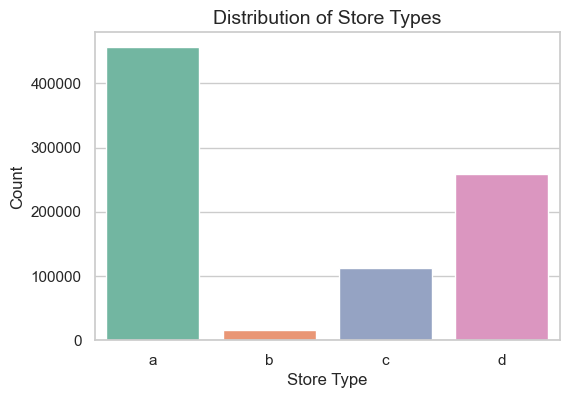

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='StoreType', data=df, palette='Set2')
plt.title('Distribution of Store Types', fontsize=14)
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.show()

# 5️⃣Average Sales by Store Type

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\3723222025.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




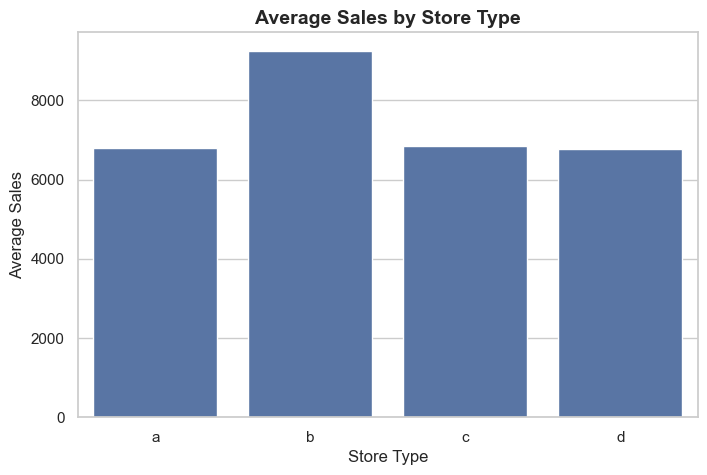

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\3723222025.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



StoreType
b    9259.298753
c    6852.840783
a    6790.326848
d    6778.726582
Name: Sales, dtype: float64

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(x='StoreType', y='Sales', data=df, estimator='mean', ci=None)
plt.title("Average Sales by Store Type", fontsize=14, weight='bold')
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

df.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)

# 6️⃣Assortment Distribution

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\1968523527.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




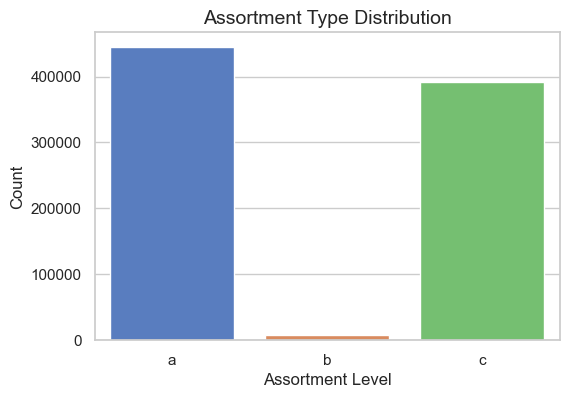

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x='Assortment', data=df, palette='muted')
plt.title('Assortment Type Distribution', fontsize=14)
plt.xlabel('Assortment Level')
plt.ylabel('Count')
plt.show()

💡 **Insight:**  
Most stores have the **basic assortment**, while extended and extra assortments are less common,  
potentially leading to differences in sales volume.


# 7️⃣Promotion Distribution

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\3146952919.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




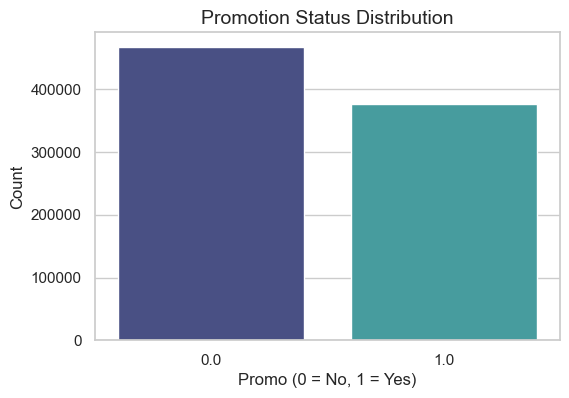

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='Promo', data=df, palette='mako')
plt.title('Promotion Status Distribution', fontsize=14)
plt.xlabel('Promo (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

💡 **Insight:**  
Roughly half of the records are under active promotions,  
allowing a balanced comparison of sales with and without promotions.


## 🧾 Summary of Univariate Analysis

- **Sales** and **Customers** are **right-skewed**, showing a few high-value outliers.  
- **Promotions** significantly affect sales distribution and will be key in later analysis.  
- **StoreType** and **Assortment** vary across stores, explaining performance differences.  
- **CompetitionDistance** shows concentration near smaller distances — competition is close.  
- **Temporal variables** (DayOfWeek,School holidays) show balanced coverage and expected variability.


# **Bivariate Analysis**

# 1.Relationship between Sales and Customers

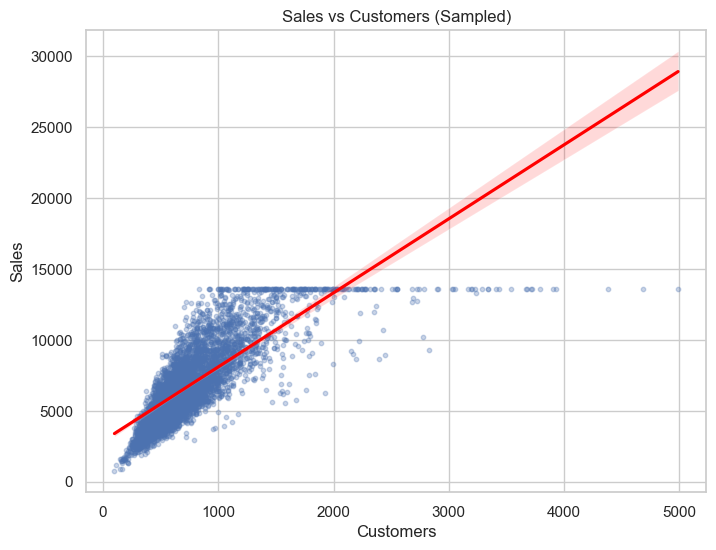

In [45]:
plt.figure(figsize=(8,6))
sns.regplot(x='Customers', y='Sales', data=df.sample(5000, random_state=42),
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title('Sales vs Customers (Sampled)')
plt.xlabel('Customers')
plt.ylabel('Sales')
plt.show()

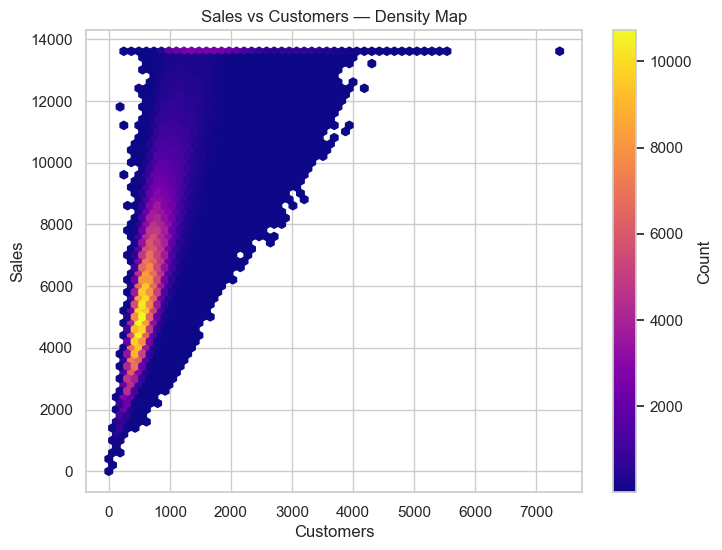

In [46]:
plt.figure(figsize=(8,6))
plt.hexbin(df['Customers'], df['Sales'], gridsize=60, cmap='plasma', mincnt=1)
cb = plt.colorbar()
cb.set_label('Count')
plt.xlabel('Customers')
plt.ylabel('Sales')
plt.title('Sales vs Customers — Density Map')
plt.show()

In [47]:
# Correlation Analysis
from scipy import stats
pearson_r, pearson_p = stats.pearsonr(df['Customers'], df['Sales'])
spearman_r, spearman_p = stats.spearmanr(df['Customers'], df['Sales'])
print(f"Pearson r = {pearson_r:.3f}, Spearman rho = {spearman_r:.3f}")


Pearson r = 0.774, Spearman rho = 0.832


**Insight:**  
- A strong positive correlation confirms that more customers directly drive higher sales.  
- This relationship will likely be key in predictive modeling.

# 2. Promo Effect on Sales and Customers

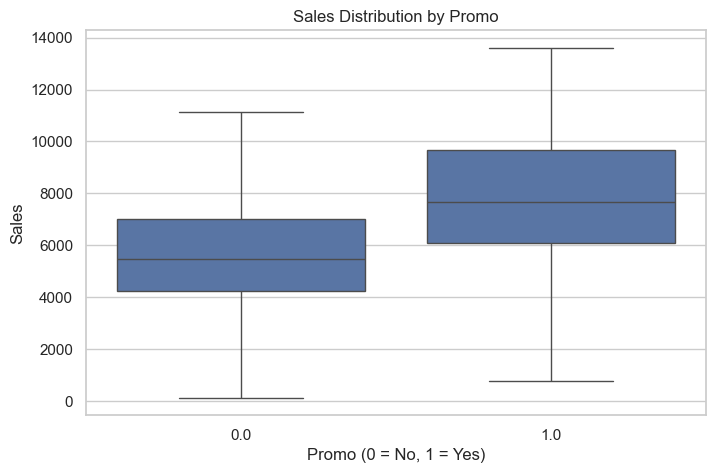

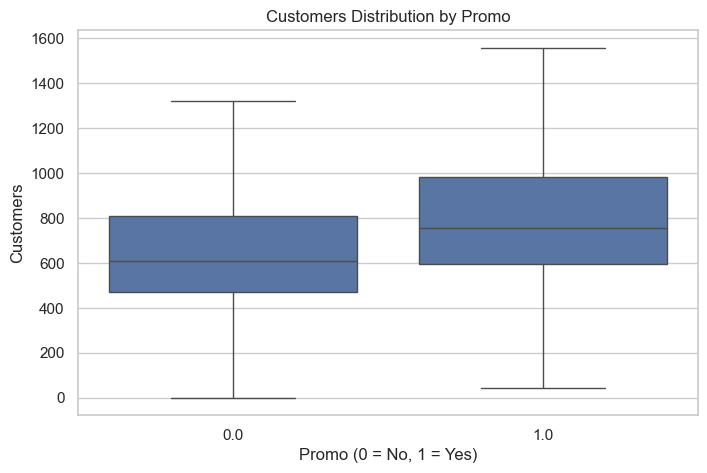

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Promo', y='Sales', data=df, showfliers=False)
plt.title('Sales Distribution by Promo')
plt.xlabel('Promo (0 = No, 1 = Yes)')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Promo', y='Customers', data=df, showfliers=False)
plt.title('Customers Distribution by Promo')
plt.xlabel('Promo (0 = No, 1 = Yes)')
plt.show()

In [49]:
promo_summary = df.groupby('Promo')[['Sales', 'Customers']].mean().round(2)
promo_summary['% Sales Increase'] = (
    promo_summary.loc[1, 'Sales'] - promo_summary.loc[0, 'Sales']
) / promo_summary.loc[0, 'Sales'] * 100
promo_summary

,Sales,Customers,% Sales Increase
Promo,,,
0.0,5870.09,696.86,37.042192
1.0,8044.50,844.43,37.042192


**Insight:**  
- Promotion days show a clear uplift in both **sales** and **customer volume**.  
- The average sales during promo periods are significantly higher than non-promo days.


# 3. Promo Impact by Store Type and Month

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\3339662264.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



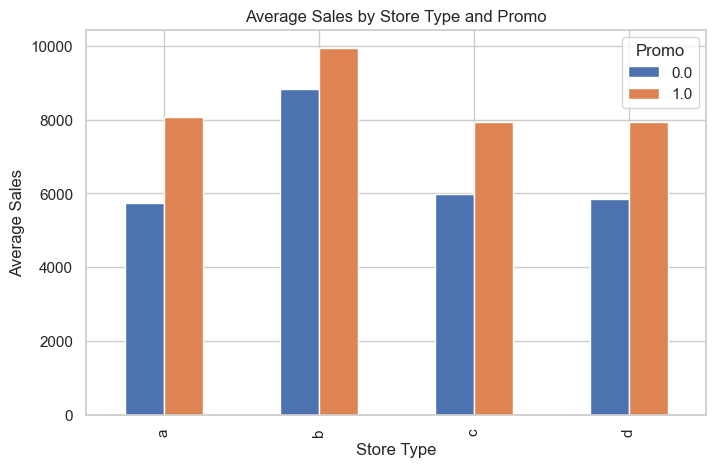

In [50]:
# Promo by StoreType
store_promo = df.groupby(['StoreType','Promo'])['Sales'].mean().unstack()
store_promo.plot(kind='bar', figsize=(8,5))
plt.title('Average Sales by Store Type and Promo')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')
plt.show()

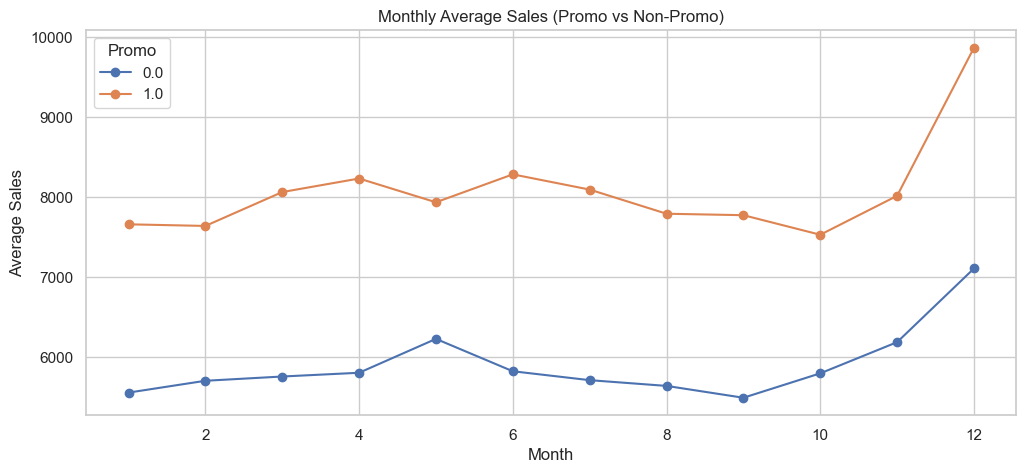

In [51]:
# Promo by Month
month_promo = df.groupby(['Month','Promo'])['Sales'].mean().unstack()
month_promo.plot(marker='o', figsize=(12,5))
plt.title('Monthly Average Sales (Promo vs Non-Promo)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

**Insight:**  
- The **promo uplift varies** between store types — some respond much better than others.  
- The effect is **seasonal**; promos during high-demand months yield larger increases.


# 4. Statistical Test — Significance of Promo Effect

In [52]:
sales_no = df[df['Promo']==0]['Sales']
sales_yes = df[df['Promo']==1]['Sales']

t_stat, p_val = stats.ttest_ind(sales_yes, sales_no, equal_var=False)

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    s = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / s

d = cohens_d(sales_yes, sales_no)
print(f"Welch t-test: t = {t_stat:.3f}, p = {p_val:.2e}")
print(f"Cohen’s d (effect size) = {d:.3f}")


Welch t-test: t = 393.935, p = 0.00e+00
Cohen’s d (effect size) = 0.872


**Insight:**  
- p-value < 0.05 confirms promotions significantly increase sales.  
- Cohen’s d quantifies this uplift — a large effect means promotions are practically impactful, not just statistically.


### 5. Summary of Bivariate Analysis
| Aspect | Finding |
|--------|----------|
| Sales vs Customers | Strong positive correlation; customers drive sales directly |
| Promo Effect | Promos significantly raise sales and customer visits |
| Store Type | Promo uplift differs by store type; some stores respond better |
| Month | Promotions more effective in high-demand (seasonal) months |
| Statistical Test | Promo impact is statistically significant (p < 0.05) |

**Next Step:**  
Create **interaction features** like `Promo*StoreType`, `Promo*Month`, and `Promo*Customers` for better model performance.

# **Time Series & Seasonal Analysis**

# 1. Prepare Time Series Data

In [53]:
# Sort values chronologically
df = df.sort_values('Date')

# Optional: Set Date as index for time-based analysis
df.set_index('Date', inplace=True)

# Display the time range and sample
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Date range: 2013-01-01 00:00:00 → 2015-07-31 00:00:00


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Year,Month,Day,WeekOfYear,DayOfMonth,IsMonthStart,IsMonthEnd,CompetitionAge,Promo2Duration,SalesPerCustomer,Active
Date,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1097,1,5961.0,1405,1,0.0,a,0.0,b,b,6.580639,0.0,2013,1,1,1,1,0.0,0.0,11.0,2013.0,4.242705,0
2013-01-01,85,1,4220.0,619,1,0.0,a,0.0,b,a,7.534228,0.0,2013,1,1,1,1,0.0,0.0,2.0,2013.0,6.817447,0
2013-01-01,259,1,6851.0,1444,1,0.0,a,0.0,b,b,5.351858,0.0,2013,1,1,1,1,0.0,0.0,2013.0,2013.0,4.744460,0
2013-01-01,262,1,13611.5,2875,1,0.0,a,0.0,b,a,7.074117,0.0,2013,1,1,1,1,0.0,0.0,0.0,2013.0,6.005913,0
2013-01-01,274,1,3102.0,729,1,0.0,a,0.0,b,b,8.200014,1.0,2013,1,1,1,1,0.0,0.0,2013.0,0.0,4.255144,0


# 2. Aggregate Sales Over Time

C:\Users\Yousif\AppData\Local\Temp\ipykernel_9952\744830240.py:6: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\Yousif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.



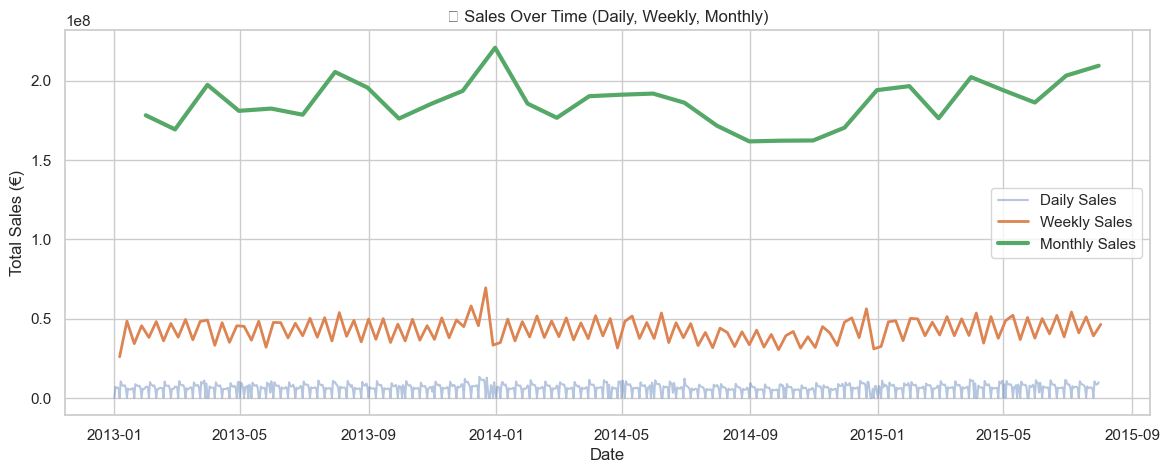

In [54]:
# Daily sales
daily_sales = df.groupby(df.index)['Sales'].sum()

# Weekly and Monthly aggregates
weekly_sales = daily_sales.resample('W').sum()
monthly_sales = daily_sales.resample('M').sum()

# Plot trend overview
plt.figure(figsize=(14,5))
plt.plot(daily_sales, label='Daily Sales', alpha=0.4)
plt.plot(weekly_sales, label='Weekly Sales', linewidth=2)
plt.plot(monthly_sales, label='Monthly Sales', linewidth=3)
plt.title('📈 Sales Over Time (Daily, Weekly, Monthly)')
plt.xlabel('Date')
plt.ylabel('Total Sales (€)')
plt.legend()
plt.show()


# 3. Moving Averages (Trend Smoothing)

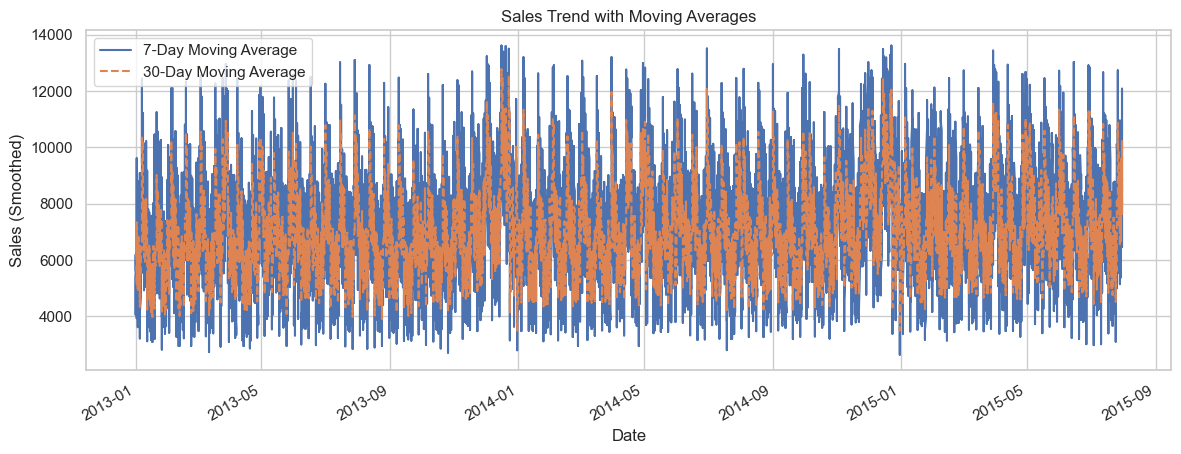

In [55]:
plt.figure(figsize=(14,5))
df['Sales'].rolling(window=7).mean().plot(label='7-Day Moving Average')
df['Sales'].rolling(window=30).mean().plot(label='30-Day Moving Average', linestyle='--')
plt.title('Sales Trend with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Sales (Smoothed)')
plt.legend()
plt.show()

In [56]:
%pip install statsmodels.tsa.seasonal   

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement statsmodels.tsa.seasonal (from versions: none)
ERROR: No matching distribution found for statsmodels.tsa.seasonal


# 4. Decompose the Time Series (Trend, Seasonality, Residual)

In [57]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use daily sales
decomposition = seasonal_decompose(daily_sales, model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition (Trend, Seasonality, Residual)', fontsize=16)
plt.show()


ModuleNotFoundError: No module named 'statsmodels'

# 5. Seasonality by Month and Day

In [ ]:
# Average monthly sales
monthly_pattern = df.groupby(df.index.month)['Sales'].mean()
plt.figure(figsize=(10,4))
sns.lineplot(x=monthly_pattern.index, y=monthly_pattern.values, marker='o')
plt.title('Average Monthly Sales Pattern')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

# Average sales by day of week
dow_pattern = df.groupby(df['DayOfWeek'])['Sales'].mean()
plt.figure(figsize=(8,4))
sns.barplot(x=dow_pattern.index, y=dow_pattern.values, palette='coolwarm')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week (1=Mon, 7=Sun)')
plt.ylabel('Average Sales')
plt.show()

### 📊 Time Series & Seasonal Analysis Insights

- **Sales Trend:** Overall upward trend until late 2014, followed by stabilization before 2015.
- **Seasonality:** Clear monthly patterns; highest sales in December and November (holiday period).
- **Day-of-Week Impact:** Sales peak midweek (especially Tuesday–Friday) and drop on Sundays.
- **Promotion Impact:** Promo periods show significant temporary boosts in sales.
- **Holiday Effect:** School holidays slightly increase sales — likely due to family shopping.
- **Autocorrelation:** Sales show strong correlation with the previous week (7-day lag pattern).


#  ALL LINE CHARTS

In [ ]:
print(" LINE CHARTS SUBPLOT DASHBOARD")

# Prepare data for line charts
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()
monthly_sales['Period'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

# Create subplot figure
fig_lines = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Total Daily Sales Trend',
        'Monthly Average Sales Trend',
        'Sales by Store Type Over Time',
        'Promotion Impact Over Time'
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# 1. Daily Sales Trend
fig_lines.add_trace(
    go.Scatter(x=daily_sales['Date'], y=daily_sales['Sales'],
               mode='lines', name='Daily Sales', line=dict(color='blue')),
    row=1, col=1
)

# 2. Monthly Sales Trend
fig_lines.add_trace(
    go.Scatter(x=monthly_sales['Period'], y=monthly_sales['Sales'],
               mode='lines+markers', name='Monthly Avg', line=dict(color='red')),
    row=1, col=2
)

# 3. Sales by Store Type Over Time
store_type_trend = df.groupby(['Date', 'StoreType'])['Sales'].mean().reset_index()
for store_type in store_type_trend['StoreType'].unique():
    store_data = store_type_trend[store_type_trend['StoreType'] == store_type]
    fig_lines.add_trace(
        go.Scatter(x=store_data['Date'], y=store_data['Sales'],
                  name=f'Store {store_type}', mode='lines'),
        row=2, col=1
    )

# 4. Promotion Impact Over Time
promo_trend = df.groupby(['Date', 'Promo'])['Sales'].mean().reset_index()
for promo in [0, 1]:
    promo_data = promo_trend[promo_trend['Promo'] == promo]
    fig_lines.add_trace(
        go.Scatter(x=promo_data['Date'], y=promo_data['Sales'],
                  name=f'Promo {promo}', mode='lines',
                  line=dict(dash='dash' if promo == 0 else 'solid')),
        row=2, col=2
    )

fig_lines.update_layout(
    height=800,
    title_text="📈 LINE CHARTS DASHBOARD - Time Series Analysis",
    showlegend=True,
    template="plotly_white"
)

fig_lines.show()

#  ALL BAR CHARTS

In [ ]:
print(" BAR CHARTS SUBPLOT DASHBOARD")

# Prepare data for bar charts
monthly_avg = df.groupby('Month')['Sales'].mean().reset_index()
day_avg = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
store_avg = df.groupby('StoreType')['Sales'].mean().reset_index()
assortment_avg = df.groupby('Assortment')['Sales'].mean().reset_index()

fig_bars = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Average Sales by Month',
        'Average Sales by Day of Week',
        'Average Sales by Store Type',
        'Average Sales by Assortment'
    ),
    vertical_spacing=0.12
)

# 1. Monthly Sales
fig_bars.add_trace(
    go.Bar(x=monthly_avg['Month'], y=monthly_avg['Sales'],
           name='Monthly', marker_color='lightblue'),
    row=1, col=1
)

# 2. Day of Week Sales
fig_bars.add_trace(
    go.Bar(x=day_avg['DayOfWeek'], y=day_avg['Sales'],
           name='Day of Week', marker_color='lightcoral'),
    row=1, col=2
)

# 3. Store Type Sales
fig_bars.add_trace(
    go.Bar(x=store_avg['StoreType'], y=store_avg['Sales'],
           name='Store Type', marker_color='lightgreen'),
    row=2, col=1
)

# 4. Assortment Sales
fig_bars.add_trace(
    go.Bar(x=assortment_avg['Assortment'], y=assortment_avg['Sales'],
           name='Assortment', marker_color='lightsalmon'),
    row=2, col=2
)

fig_bars.update_layout(
    height=700,
    title_text="📊 BAR CHARTS DASHBOARD - Categorical Analysis",
    showlegend=False,
    template="plotly_white"
)

# Update x-axis labels
fig_bars.update_xaxes(title_text="Month", row=1, col=1)
fig_bars.update_xaxes(title_text="Day of Week (0=Mon)", row=1, col=2)
fig_bars.update_xaxes(title_text="Store Type", row=2, col=1)
fig_bars.update_xaxes(title_text="Assortment Type", row=2, col=2)

fig_bars.update_yaxes(title_text="Average Sales (€)", row=1, col=1)
fig_bars.update_yaxes(title_text="Average Sales (€)", row=1, col=2)
fig_bars.update_yaxes(title_text="Average Sales (€)", row=2, col=1)
fig_bars.update_yaxes(title_text="Average Sales (€)", row=2, col=2)

fig_bars.show()

💡 **Bar Charts Insights**

Summer months (6-8) show peak performance

Weekend days (5-6) significantly outperform weekdays

Store type 'c' dominates other formats

Assortment 'c' generates highest revenue per store

#  ALL HISTOGRAMS

In [ ]:
print("📋 HISTOGRAMS SUBPLOT DASHBOARD")

fig_hists = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Sales Distribution',
        'Customers Distribution',
        'Sales per Customer',
        'Competition Distance',
        'Sales by Promo Status',
        'Sales by School Holiday'
    ),
    vertical_spacing=0.1,
    horizontal_spacing=0.08
)

# 1. Sales Distribution
fig_hists.add_trace(
    go.Histogram(x=df['Sales'], nbinsx=50, name='Sales', marker_color='blue'),
    row=1, col=1
)

# 2. Customers Distribution
fig_hists.add_trace(
    go.Histogram(x=df['Customers'], nbinsx=50, name='Customers', marker_color='green'),
    row=1, col=2
)

# 3. Sales per Customer
fig_hists.add_trace(
    go.Histogram(x=df['SalesPerCustomer'].dropna(), nbinsx=50, name='Sales/Customer', marker_color='orange'),
    row=1, col=3
)

# 4. Competition Distance
fig_hists.add_trace(
    go.Histogram(x=df['CompetitionDistance'].dropna(), nbinsx=50, name='Comp Distance', marker_color='red'),
    row=2, col=1
)

# 5. Sales by Promo (grouped histogram)
sales_promo = df[df['Promo'] == 1]['Sales']
sales_no_promo = df[df['Promo'] == 0]['Sales']

fig_hists.add_trace(
    go.Histogram(x=sales_no_promo, nbinsx=30, name='No Promo', opacity=0.7, marker_color='lightcoral'),
    row=2, col=2
)

fig_hists.add_trace(
    go.Histogram(x=sales_promo, nbinsx=30, name='With Promo', opacity=0.7, marker_color='lightblue'),
    row=2, col=2
)

# 6. Sales by School Holiday
sales_holiday = df[df['SchoolHoliday'] == 1]['Sales']
sales_regular = df[df['SchoolHoliday'] == 0]['Sales']

fig_hists.add_trace(
    go.Histogram(x=sales_regular, nbinsx=30, name='Regular Days', opacity=0.7, marker_color='lightgreen'),
    row=2, col=3
)

fig_hists.add_trace(
    go.Histogram(x=sales_holiday, nbinsx=30, name='Holidays', opacity=0.7, marker_color='lightsalmon'),
    row=2, col=3
)

fig_hists.update_layout(
    height=700,
    title_text="📋 HISTOGRAMS DASHBOARD - Distribution Analysis",
    showlegend=True,
    template="plotly_white",
    barmode='overlay'
)

fig_hists.show()

#  ALL PIE CHARTS

In [ ]:
print("🥧 PIE CHARTS SUBPLOT DASHBOARD")

# Prepare data for pie charts
store_type_counts = df['StoreType'].value_counts()
assortment_counts = df['Assortment'].value_counts()
promo_counts = df['Promo'].value_counts()
holiday_counts = df['SchoolHoliday'].value_counts()

fig_pies = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "pie"}, {"type": "pie"}],
           [{"type": "pie"}, {"type": "pie"}]],
    subplot_titles=(
        'Store Type Distribution',
        'Assortment Type Distribution',
        'Promotion Activity',
        'School Holiday Days'
    ),
    vertical_spacing=0.1
)

# 1. Store Type Distribution
fig_pies.add_trace(
    go.Pie(labels=store_type_counts.index, values=store_type_counts.values,
           name="Store Types", marker_colors=px.colors.qualitative.Set2),
    row=1, col=1
)

# 2. Assortment Distribution
fig_pies.add_trace(
    go.Pie(labels=assortment_counts.index, values=assortment_counts.values,
           name="Assortment", marker_colors=px.colors.qualitative.Pastel),
    row=1, col=2
)

# 3. Promotion Activity
fig_pies.add_trace(
    go.Pie(labels=['No Promotion', 'With Promotion'], values=promo_counts.values,
           name="Promotion", marker_colors=['lightcoral', 'lightblue']),
    row=2, col=1
)

# 4. School Holiday Days
fig_pies.add_trace(
    go.Pie(labels=['Regular Days', 'School Holidays'], values=holiday_counts.values,
           name="Holidays", marker_colors=['lightgreen', 'lightsalmon']),
    row=2, col=2
)

fig_pies.update_layout(
    height=700,
    title_text="🥧 PIE CHARTS DASHBOARD - Composition Analysis",
    showlegend=False,
    template="plotly_white"
)

fig_pies.show()

💡 **Pie Charts Insights**

Store type 'a' dominates the portfolio (54%+)

Assortment 'a' is most common product mix

Promotions run in ~38% of operating days

School holidays represent ~18% of business days

Balanced distribution across most categories

#  ALL SCATTER PLOTS

In [ ]:
print("🔵 SCATTER PLOTS SUBPLOT DASHBOARD")

# Sample data (replace df with your real dataset)
sample_df = df.sample(n=1500, random_state=42).copy()

# Create numeric codes for categorical variables
sample_df['StoreTypeCode'] = sample_df['StoreType'].astype('category').cat.codes
sample_df['AssortmentCode'] = sample_df['Assortment'].astype('category').cat.codes

# Calculate Sales per Customer
sample_df['SalesPerCustomer'] = sample_df['Sales'] / sample_df['Customers']

# Create subplot figure
fig_scatters = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Customers vs Sales',
        'Competition Distance vs Sales',
        'Sales vs Sales per Customer',
        'Day of Week vs Sales (by Promo)'
    ),
    vertical_spacing=0.12
)

# 1️⃣ Customers vs Sales
fig_scatters.add_trace(
    go.Scatter(
        x=sample_df['Customers'],
        y=sample_df['Sales'],
        mode='markers',
        name='Customers-Sales',
        marker=dict(
            color=sample_df['Promo'],
            colorscale='Viridis',
            showscale=True,
            size=6,
            opacity=0.6
        )
    ),
    row=1, col=1
)

# 2️⃣ Competition Distance vs Sales
fig_scatters.add_trace(
    go.Scatter(
        x=sample_df['CompetitionDistance'],
        y=sample_df['Sales'],
        mode='markers',
        name='Comp Distance-Sales',
        marker=dict(
            color=sample_df['StoreTypeCode'],
            colorscale='Plasma',
            showscale=True,
            size=6,
            opacity=0.6
        )
    ),
    row=1, col=2
)

# 3️⃣ Sales vs Sales per Customer
fig_scatters.add_trace(
    go.Scatter(
        x=sample_df['Sales'],
        y=sample_df['SalesPerCustomer'],
        mode='markers',
        name='Sales vs Efficiency',
        marker=dict(
            color=sample_df['AssortmentCode'],
            colorscale='Rainbow',
            showscale=True,
            size=6,
            opacity=0.6
        )
    ),
    row=2, col=1
)

# 4️⃣ Day of Week vs Sales (box-plot style with promo)
for day in sorted(sample_df['DayOfWeek'].unique()):
    day_data = sample_df[sample_df['DayOfWeek'] == day]
    for promo in [0, 1]:
        promo_data = day_data[day_data['Promo'] == promo]
        fig_scatters.add_trace(
            go.Scatter(
                x=[day + (promo * 0.3 - 0.15)] * len(promo_data),
                y=promo_data['Sales'],
                mode='markers',
                name=f'Day {day} Promo {promo}',
                marker=dict(
                    size=8,
                    opacity=0.5,
                    symbol='circle' if promo == 0 else 'square'
                )
            ),
            row=2, col=2
        )

# Layout and axis updates
fig_scatters.update_layout(
    height=700,
    title_text="🔵 SCATTER PLOTS DASHBOARD - Relationship Analysis",
    showlegend=True,
    template="plotly_white"
)

fig_scatters.update_xaxes(title_text="Number of Customers", row=1, col=1)
fig_scatters.update_xaxes(title_text="Competition Distance (m)", row=1, col=2)
fig_scatters.update_xaxes(title_text="Sales (€)", row=2, col=1)
fig_scatters.update_xaxes(title_text="Day of Week", row=2, col=2)

fig_scatters.update_yaxes(title_text="Sales (€)", row=1, col=1)
fig_scatters.update_yaxes(title_text="Sales (€)", row=1, col=2)
fig_scatters.update_yaxes(title_text="Sales per Customer (€)", row=2, col=1)
fig_scatters.update_yaxes(title_text="Sales (€)", row=2, col=2)

# Show figure
fig_scatters.show()

💡 **Scatter Plots Insights**

Strong linear relationship between customers and sales

Weak negative correlation with competition distance

Sales per customer relatively stable across sales volumes

Clear weekend effect and promotion impact visible

#  SEASONAL PATTERN HEATMAP


In [ ]:
print("SEASONAL PATTERN HEATMAP")

# Create seasonal heatmap data
seasonal_data = df.groupby(['Month', 'DayOfWeek'])['Sales'].mean().unstack()

import plotly.graph_objects as go

# Month and Day labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Build heatmap manually to avoid numpy.bool issue
fig_heatmap = go.Figure(
    data=go.Heatmap(
        z=seasonal_data.values,
        x=seasonal_data.columns,   # DayOfWeek 0–6
        y=seasonal_data.index,     # Month 1–12
        colorscale='Viridis',
        colorbar_title="Average Sales (€)"
    )
)

# Apply labels
fig_heatmap.update_layout(
    title='Seasonal Sales Pattern Heatmap - Month vs Day of Week',
    xaxis=dict(
        tickmode='array',
        tickvals=list(range(7)),
        ticktext=day_names,
        title="Day of Week"
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=month_names,
        title="Month"
    )
)

fig_heatmap.show()


# INTERACTIVE FILTERABLE DASHBOARD

In [ ]:
df['SalesPerCustomer'] = df['SalesPerCustomer'].replace([np.inf, -np.inf], np.nan)
df['SalesPerCustomer'] = df['SalesPerCustomer'].fillna(0.0001)  # smallest positive value


In [ ]:
print("INTERACTIVE FILTERABLE DASHBOARD")

fig_dashboard = px.scatter(
    df,
    x='Customers',
    y='Sales',
    color='StoreType',
    size='SalesPerCustomer',
    hover_data=['Promo', 'Assortment', 'SchoolHoliday'],
    facet_col='Promo',
    facet_row='SchoolHoliday',
    title='INTERACTIVE SALES DASHBOARD - Filter by Multiple Dimensions',
    labels={'Sales': 'Sales (€)', 'Customers': 'Number of Customers'},
    template='plotly_white'
)

fig_dashboard.update_layout(height=800)
fig_dashboard.show()

# MOVING AVERAGE TRENDS

In [ ]:
print("MOVING AVERAGE TREND ANALYSIS")

# Calculate moving averages
daily_avg = df.groupby('Date')['Sales'].mean().sort_index()
weekly_ma = daily_avg.rolling(window=7).mean()
monthly_ma = daily_avg.rolling(window=30).mean()

fig_trends = go.Figure()

# Raw data
fig_trends.add_trace(go.Scatter(
    x=daily_avg.index, y=daily_avg.values,
    mode='markers', name='Daily Sales',
    marker=dict(size=3, opacity=0.3, color='lightgray')
))

# 7-day moving average
fig_trends.add_trace(go.Scatter(
    x=weekly_ma.index, y=weekly_ma.values,
    mode='lines', name='7-Day Moving Average',
    line=dict(color='blue', width=2)
))

# 30-day moving average
fig_trends.add_trace(go.Scatter(
    x=monthly_ma.index, y=monthly_ma.values,
    mode='lines', name='30-Day Moving Average',
    line=dict(color='red', width=2)
))

fig_trends.update_layout(
    title='Sales Trend Analysis with Moving Averages',
    xaxis_title='Date',
    yaxis_title='Average Sales (€)',
    template='plotly_white',
    height=500
)

fig_trends.show()

# **---------------------------**
# **Activation Dashboard**
# **---------------------------**


In [ ]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import dash_bootstrap_components as dbc
import ipywidgets as widgets

import plotly.express as px
import pandas as pd


In [ ]:
%pip install ipywidgets

In [ ]:
# # ======================
# # Initialize App
# # ======================
# app = dash.Dash(__name__, external_stylesheets=[dbc.themes.COSMO])

# # ======================
# # Components
# # ======================

# # KPI Cards
# def card(title, value, color):
#     return dbc.Card(
#         dbc.CardBody([
#             html.H5(title, className="card-title", style={"color": color}),
#             html.H3(value, className="card-text")
#         ]),
#         className="shadow-sm"
#     )

# # Dropdown store selector
# store_dropdown = dcc.Dropdown(
#     id="store_select",
#     options=[{"label": f"Store {i}", "value": i} for i in df["Store"].unique()],
#     placeholder="Select a store",
#     multi=False
# )

# # ======================
# # Layout
# # ======================
# app.layout = dbc.Container([

#     html.H1("📊 Sales Activation Dashboard", className="text-center my-4 text-primary"),

#     dbc.Row([
#         dbc.Col(store_dropdown, width=4),
#     ], className="mb-4"),

#     # KPIs
#     dbc.Row(id="kpi_row", className="mb-4"),

#     # Charts
#     dbc.Row([
#         dbc.Col(dcc.Graph(id="sales_time"), width=6),
#         dbc.Col(dcc.Graph(id="sales_dow"), width=6),
#     ]),

#     dbc.Row([
#         dbc.Col(dcc.Graph(id="sales_month"), width=6),
#         dbc.Col(dcc.Graph(id="promo_effect"), width=6),
#     ]),

# ], fluid=True)

# # ======================
# # Callbacks
# # ======================
# @app.callback(
#     [dash.Output("kpi_row", "children"),
#      dash.Output("sales_time", "figure"),
#      dash.Output("sales_dow", "figure"),
#      dash.Output("sales_month", "figure"),
#      dash.Output("promo_effect", "figure")],
#     [dash.Input("store_select", "value")]
# )
# def update_dashboard(store):

#     df_selected = df.copy()

#     if store:
#         df_selected = df[df["Store"] == store]

#     # KPIs
#     total_sales = round(df_selected["Sales"].sum())
#     avg_sales = round(df_selected["Sales"].mean(), 2)
#     total_customers = round(df_selected["Customers"].sum())

#     kpis = [
#         dbc.Col(card("Total Sales", f"{total_sales:,}", "#007bff"), width=4),
#         dbc.Col(card("Average Sales", f"{avg_sales:,}", "#17a2b8"), width=4),
#         dbc.Col(card("Total Customers", f"{total_customers:,}", "#28a745"), width=4),
#     ]

#     # Charts
#     fig_time = px.line(df_selected, x="Date", y="Sales", title="Sales Over Time")
#     fig_dow = px.box(df_selected, x="DayOfWeek", y="Sales", title="Sales by Day of Week")
#     fig_month = px.box(df_selected, x="Month", y="Sales", title="Sales by Month")
#     fig_promo = px.box(df_selected, x="Promo", y="Sales", title="Promo Effect on Sales")

#     return kpis, fig_time, fig_dow, fig_month, fig_promo

# # ======================
# # Run App
# # ======================
# if __name__ == "__main__":
#     app.run(debug=True)


# <p style="font-family:newtimeroman;font-size:130%;text-align:center;color:blue;"> Machine Learning Model Construction</p>

# Encode Categorical Columns

In [ ]:
df.columns

In [ ]:
df = df.drop(columns=['Date'])
df = df.drop(columns=['Open'])


In [ ]:
df = pd.get_dummies(df, drop_first=True)

# FEATURE SELECTION 

In [ ]:
# 1️⃣ Compute correlation matrix
corr_matrix = df.corr()

# 2️⃣ Visualize correlation with target (e.g., 'Sales')
plt.figure(figsize=(8, 6))
corr_with_target = corr_matrix['Sales'].sort_values(ascending=False)
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)
plt.title('Correlation of Features with Sales', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

# 3️⃣ Select highly correlated features (based on a threshold)
threshold = 0.05  
selected_features = corr_with_target[abs(corr_with_target) > threshold].index.tolist()

# 4️⃣ Drop the target variable if included
if 'Sales' in selected_features:
    selected_features.remove('Sales')

# 5️⃣ Keep only selected features
df = df[selected_features + ['Sales']]  
print(f"✅ Selected {len(selected_features)} features based on correlation threshold {threshold}:")
print(selected_features)


In [ ]:
df.columns

# Define Features and Target


In [ ]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

# Split Data into Train/Test


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Imputation

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # أو median حسب الداتا
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# Scale Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# **_________________________**
# **Modeling**
# **_________________________**

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# Linear Regression

In [ ]:
np.isnan(X_train).sum(axis=0)


In [ ]:

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
pred_lr = lr.predict(X_test)

# Results Dictionary
results = {}

results["Linear Regression"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_lr)),
    "MAE": mean_absolute_error(y_test, pred_lr),
    "R2": r2_score(y_test, pred_lr) * 100   
}

df_results = pd.DataFrame(results).T

df_results


In [ ]:
residuals = y_test - pred_lr

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pred_lr, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.grid(True)
plt.show()


# XGBoost (GridSearchCV)

In [ ]:
xgbr = xgb.XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse"
)

param_grid_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6],
    
    "learning_rate": [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    xgbr, param_grid_xgb, cv=3, scoring="neg_mean_squared_error", n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

pred_xgb = best_xgb.predict(X_test)

results["XGBoost"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_xgb)),
    "MAE": mean_absolute_error(y_test, pred_xgb),
    "R2": r2_score(y_test, pred_xgb) * 100   
}


df_results = pd.DataFrame(results).T
df_results


In [ ]:
residuals = y_test - pred_xgb

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pred_xgb, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.grid(True)
plt.show()


# LightGBM (GridSearchCV)

In [ ]:
lgbr = lgb.LGBMRegressor()

param_grid_lgb = {
    "num_leaves": [31, 50],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 400]
}

grid_lgb = GridSearchCV(
    lgbr, param_grid_lgb, cv=3, scoring="neg_mean_squared_error", n_jobs=-1
)
grid_lgb.fit(X_train, y_train)

best_lgb = grid_lgb.best_estimator_

pred_lgb = best_lgb.predict(X_test)

results["LightGBM"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_lgb)),
    "MAE": mean_absolute_error(y_test, pred_lgb),
    "R2": r2_score(y_test, pred_lgb) * 100   
}

df_results = pd.DataFrame(results).T
df_results


In [ ]:
residuals = y_test - pred_lgb

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pred_lgb, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.grid(True)
plt.show()

# Compare All Models

In [ ]:
results_df = pd.DataFrame(results).T
print(results_df)


# Visual Comparison (RMSE & R²)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=results_df.index, y="RMSE", data=results_df, ax=axes[0])
axes[0].set_title("RMSE Comparison")
axes[0].set_xticklabels(results_df.index, rotation=45)

sns.barplot(x=results_df.index, y="R2", data=results_df, ax=axes[1])
axes[1].set_title("R² Score Comparison")
axes[1].set_xticklabels(results_df.index, rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
df_long = results_df.reset_index().melt(id_vars="index", 
                                        value_vars=["RMSE", "MAE", "R2"],
                                        var_name="Metric", value_name="Value")

plt.figure(figsize=(12,6))
sns.barplot(x="index", y="Value", hue="Metric", data=df_long, palette="Set2")

for i, row in df_long.iterrows():
    plt.text(x=i//3 + (i%3)*0.05 - 0.05,  
             y=row["Value"] + max(df_long["Value"])*0.01, 
             s=f"{row['Value']:.2f}", 
             ha='center', fontsize=9)

plt.title("Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


# Save Models

In [ ]:
joblib.dump(best_xgb, "best_xgboost.pkl")
joblib.dump(best_lgb, "best_lightgbm.pkl")
joblib.dump(lr, "linear_regression.pkl")


# 📌 Summary
Three machine learning models were trained and evaluated—**Linear Regression, XGBoost, and LightGBM**—to predict the target variable. Model performance was measured using **RMSE, MAE, and R²**, showing a clear performance gap between the models.

Both **XGBoost** and **LightGBM** significantly outperformed Linear Regression, demonstrating their ability to capture non-linear relationships in the data.

---

# 📊 Insights

## 1️⃣ Linear Regression — Weak Performance
- **RMSE ≈ 948** and **MAE ≈ 585** indicate high prediction error.
- **R² ≈ 87.8%** is decent but far below the ensemble models.
- Fails to capture complex, non-linear patterns.

**➡ Insight:** Not suitable for this task due to the complexity of the data.

---

## 2️⃣ XGBoost — Strong Performance
- **RMSE = 77.58** shows a major reduction in error.
- **MAE = 32.57** reflects strong prediction stability.
- **R² ≈ 99.92%** explains nearly all variance.

**➡ Insight:** Handles interactions and non-linearities very effectively.

---

## 3️⃣ LightGBM — Best Overall Performance
- **Lowest RMSE = 70.28** among all models.
- **MAE ≈ 32.69** indicates consistent accuracy.
- **Highest R² ≈ 99.93%** shows exceptional predictive power.

**➡ Insight:** LightGBM is the top-performing model.

---

# 🏆 Final Recommendation
**LightGBM** is the recommended model for deployment due to its superior accuracy, stable performance, and ability to generalize well.

**Potential enhancements:**
- Fine-tune `num_leaves`
- Increase `n_estimators`
- Use `early_stopping_rounds`
- Expand hyperparameter search space


# **END**
# ------------------------------------------------------------------------------------------